In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product, visualize_policy_suspension_impact
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price, show_two_panel_conversion_by_brand_price
from etl.price import visualize_conversion_by_equipment_type_brand_price, show_conversion_by_price_dashboard, show_product_type_price_conversion_heatmap
from etl.season import visualize_conversion_by_season, visualize_regional_seasonality
from etl.period import visualize_conversion_by_year, report_best_and_worst_months, show_conversion_by_price_over_time, overlay_all_years_on_one_plot
from etl.period import visualize_conversion_by_prices_sweet_spot_shift, visualize_decision_times, show_decision_time_dashboard
from etl.product import visualise_heat_pump_performance, show_product_type_by_brand_heatmap, show_product_type_by_agency_heatmap, show_brand_by_product_type_heatmap


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 37,008 quotes from 25,716 customers


In [2]:
customers = aggregate_customer(df_clean)

Quote-level columns created:
  - out_of_pocket: 34,991 values
  - subsidy_issue: 9,076 issues (24.5%)

✅ Customer dataset created: 25,716 customers
✅ Total columns: 52
✅ Key columns now available:
   - decision_days: from customer_duration_days
   - price_cv: from std_out_of_pocket / avg_out_of_pocket
   - quote_count: alias for total_quotes
   - main_brand: most common brand per customer
   - price_range: 1142 avg
   - price_volatility: 0.26 avg
subsidy_issue_type
No Issues            18660
Both                  2480
CEE Only              2361
MaPrimeRénov Only     2215
Name: count, dtype: int64

✅ Saved to 'customer_master_data.csv'


In [3]:
customers = pd.read_csv('customer_master_data.csv')


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.363130           18660           6776.0
True                      0.476616            7056           3363.0

Chi-square p-value: 6.718504e-62
Statistically significant: YES

Conversion without issues: 36.31%
Conversion with issues: 47.66%
Difference: 11.3 percentage points
Customer-level finding: +11.3 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.40
  With issues: 1.55
  Ratio: 1.11x

avg_quote_amount:
  No issues: 6137.73
  With issues: 9895.80
  Ratio: 1.61x

max_quote_amount:
  No issues: 6557.78
  With issues: 10828.77
  Ratio: 1.65x

customer_duration_days:
  No issues: 19.20
  With issues: 26.05
  Ratio: 1.36x

price_range:
  No issues: 899.87
  With issues: 1770.19
  Ratio: 1.97x

multiple_quotes:
  No issues: 

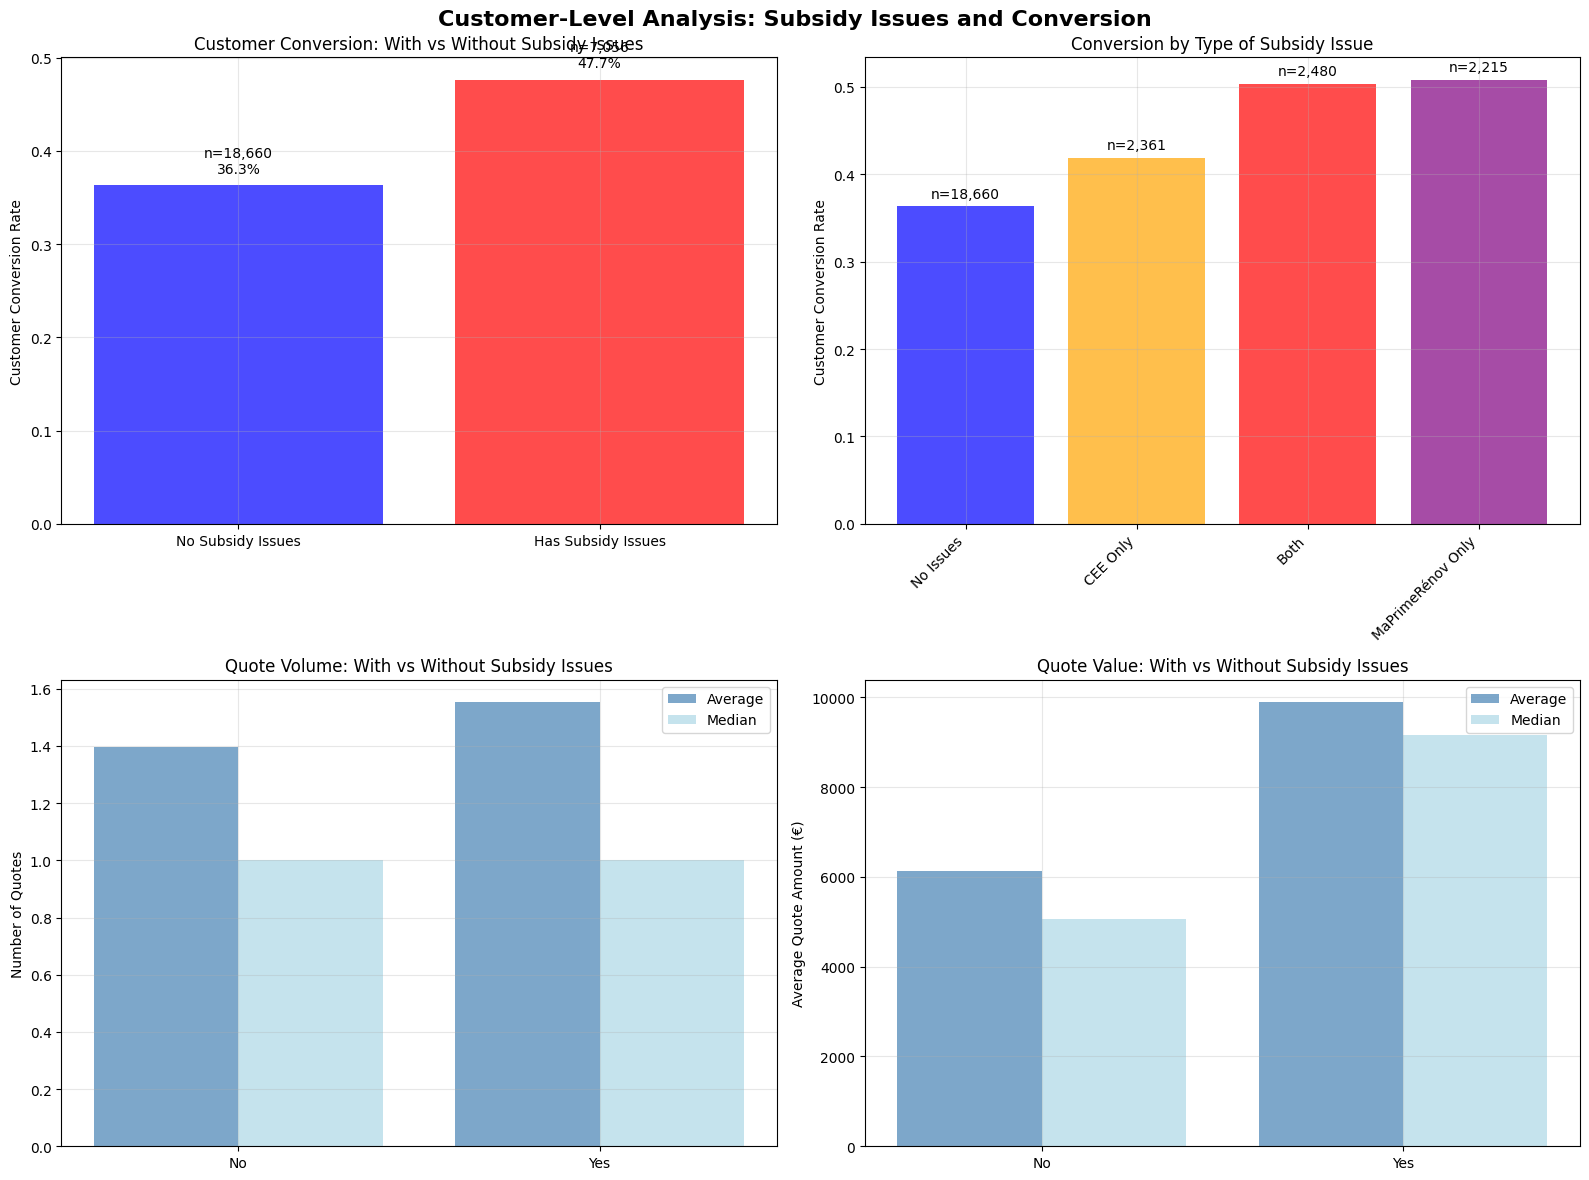


Policy Suspension Impact

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309
Unique values in during_suspension: [False  True]

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.399886  21126
During Suspension  0.357215   2959

Suspension impact p-value: 0.0000
Statistically significant: YES

Product mix during suspensions:
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
during_suspension                                             
False                    19.4    28.4       18.5    9.9   23.7
True                     37.9    27.4       10.2    7.5   17.1


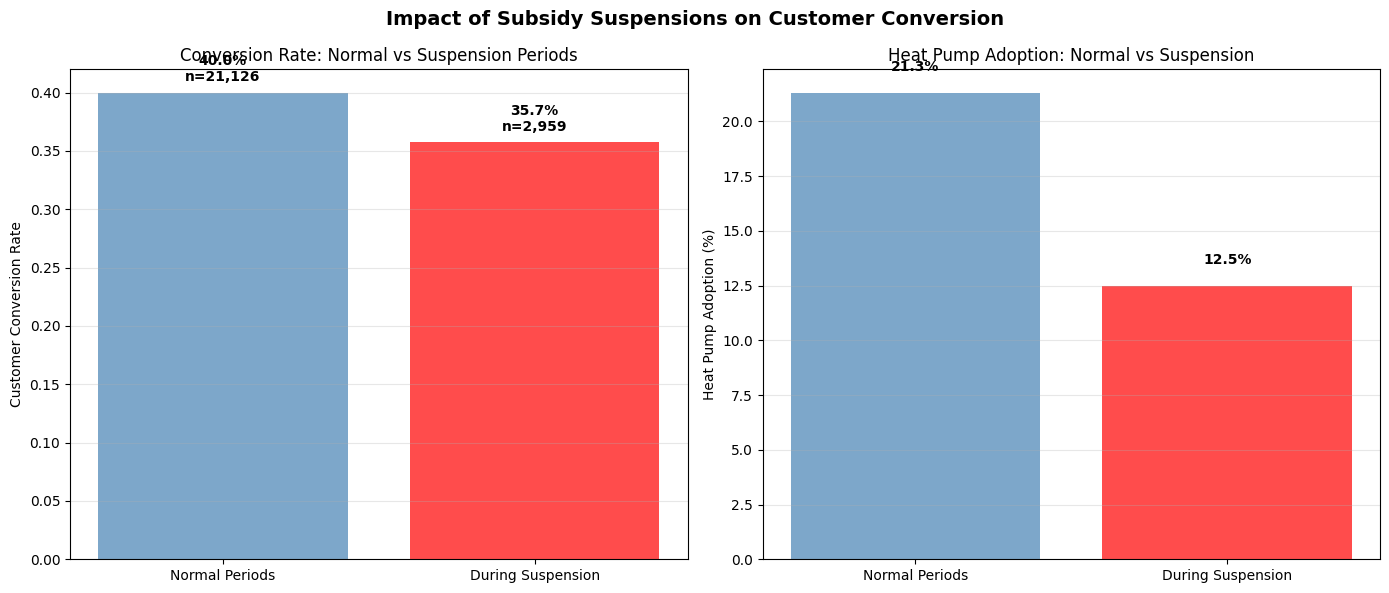

Unique values in main_product_family:
main_product_family
Chaudière                           7127
Poêle                               5838
Climatisation                       5342
Pompe à chaleur                     4322
ECS : Chauffe-eau ou adoucisseur    1386
Photovoltaïque                       645
Emetteur de chauffage  ou chappe     310
Autres                               279
Unknown                              168
Appareil hybride                     157
Accessoire de pose                    70
Produit VMC                           58
Plomberie Sanitaire                   13
Régulation ou électricité              1
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           7127
Poêle                               5838
Climatisation                       5342
Pompe à chaleur                     4322
ECS : Chauffe-eau ou adoucisseur    1386
Photovoltaïque                       645
Emetteur de chauffage  ou chappe     310
Autres              

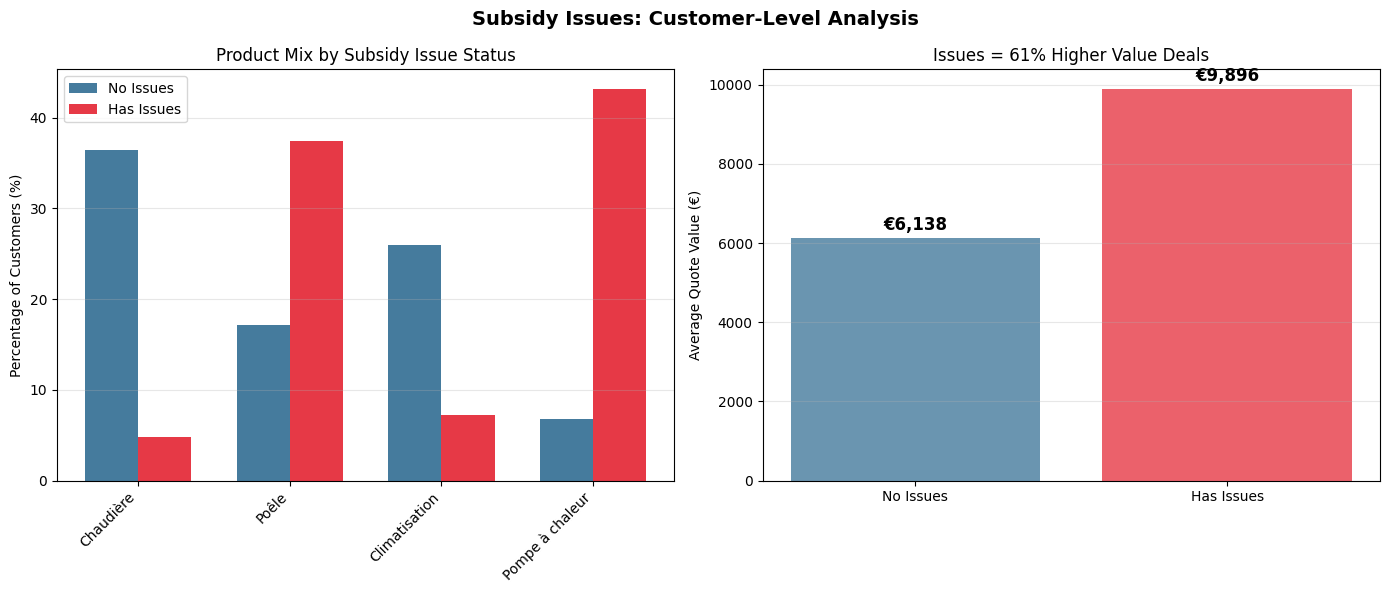


Threshold effect

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309


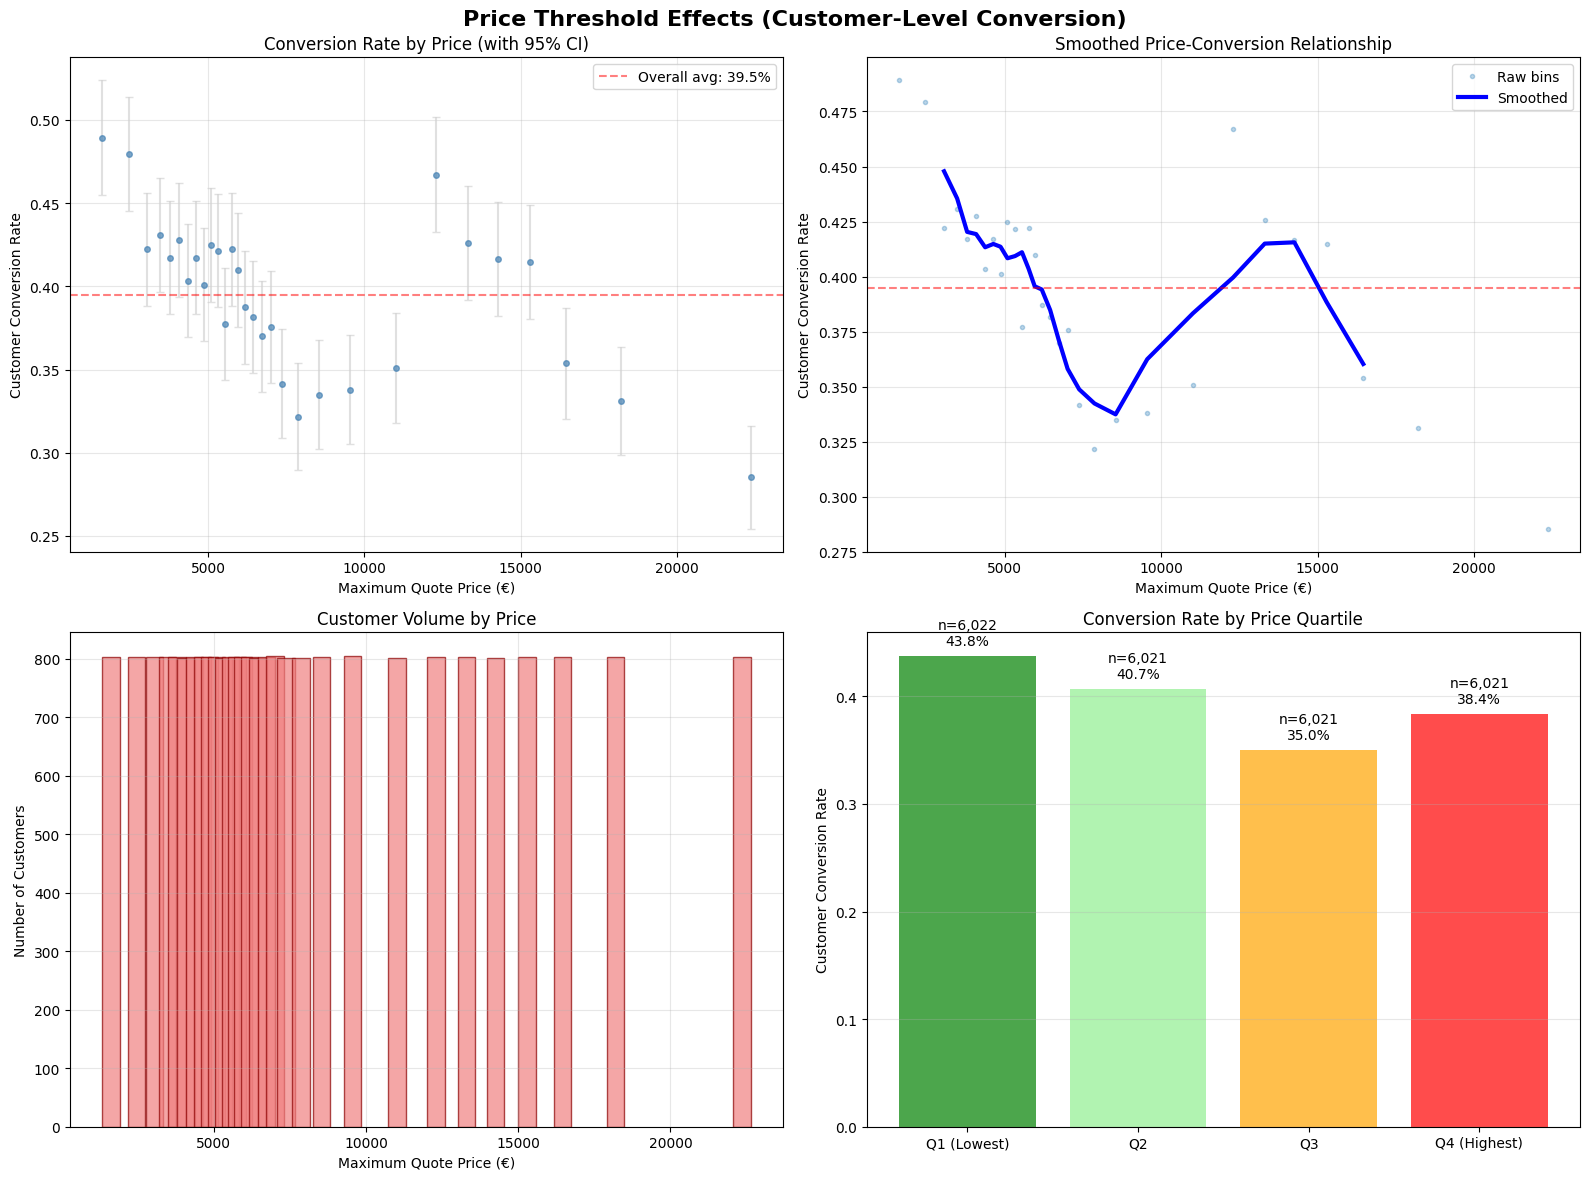


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 43.8% (n=6,022)
  Q2: 40.7% (n=6,021)
  Q3: 35.0% (n=6,021)
  Q4 (Highest): 38.4% (n=6,021)

Difference between lowest and highest quartile: 5.4 percentage points

Sweet spots (above-average conversion):
  €1,622: 48.9% (n=803)
  €2,460: 47.9% (n=803)
  €3,057: 42.2% (n=803)
  €3,475: 43.1% (n=803)
  €3,794: 41.7% (n=803)
  €4,081: 42.8% (n=802)
  €4,370: 40.4% (n=803)
  €4,632: 41.7% (n=803)
  €4,861: 40.1% (n=803)
  €5,084: 42.5% (n=803)
  €5,326: 42.1% (n=802)
  €5,759: 42.2% (n=803)
  €5,954: 41.0% (n=803)
  €12,299: 46.7% (n=803)
  €13,308: 42.6% (n=803)
  €14,256: 41.6% (n=802)
  €15,286: 41.5% (n=803)

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
price_quartile                                                
Q1_Low                  

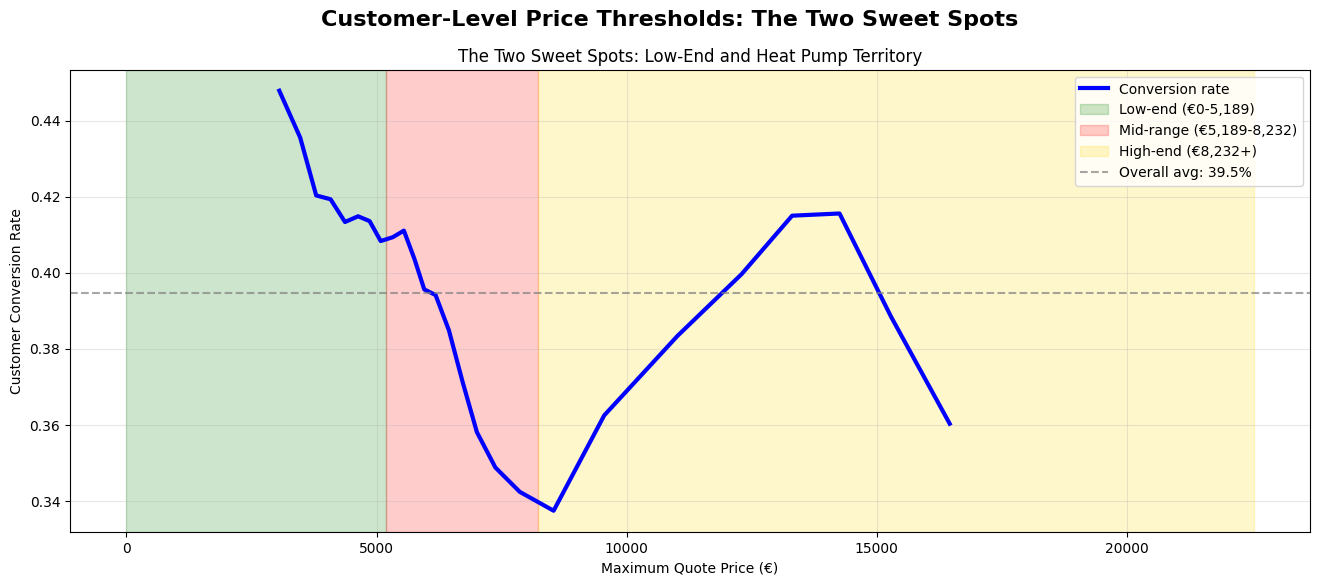

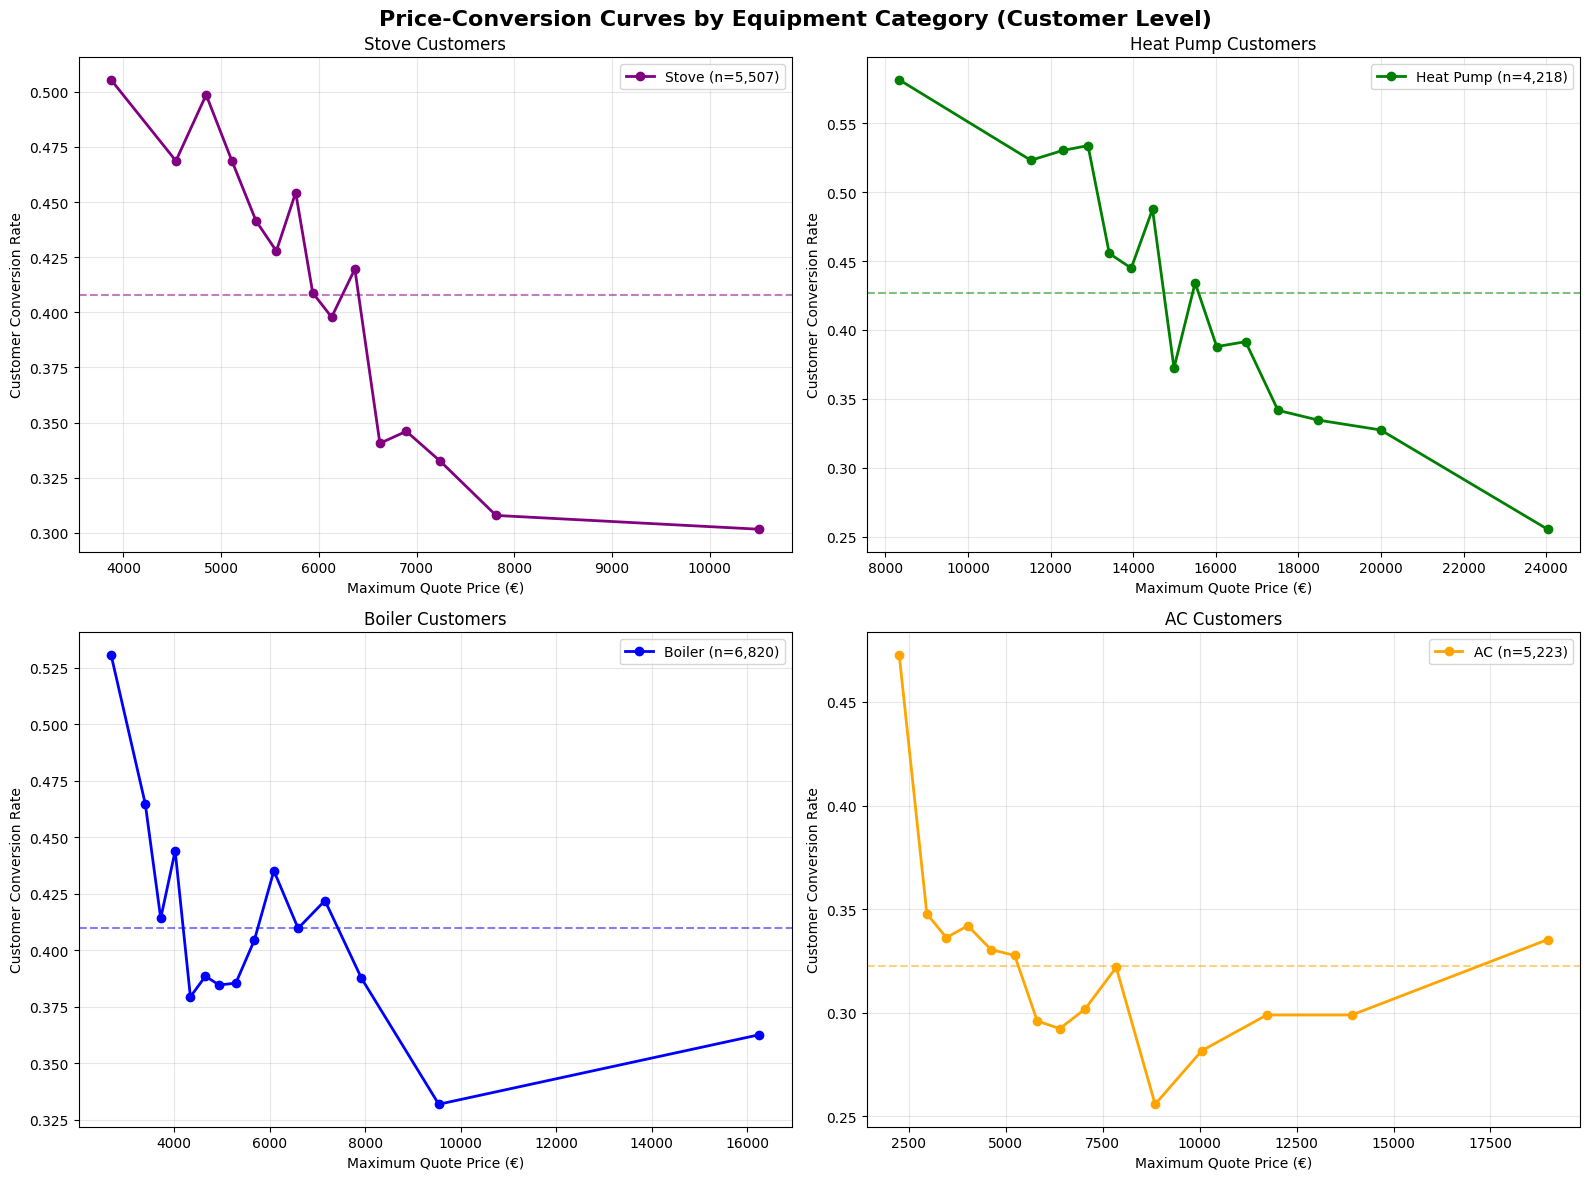


Conversion by Brand Price

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'MCZ', 'E.L.M. LEBLANC', 'FRISQUET', 'SAUNIER DUVAL', 'DE DIETRICH', 'HITACHI']


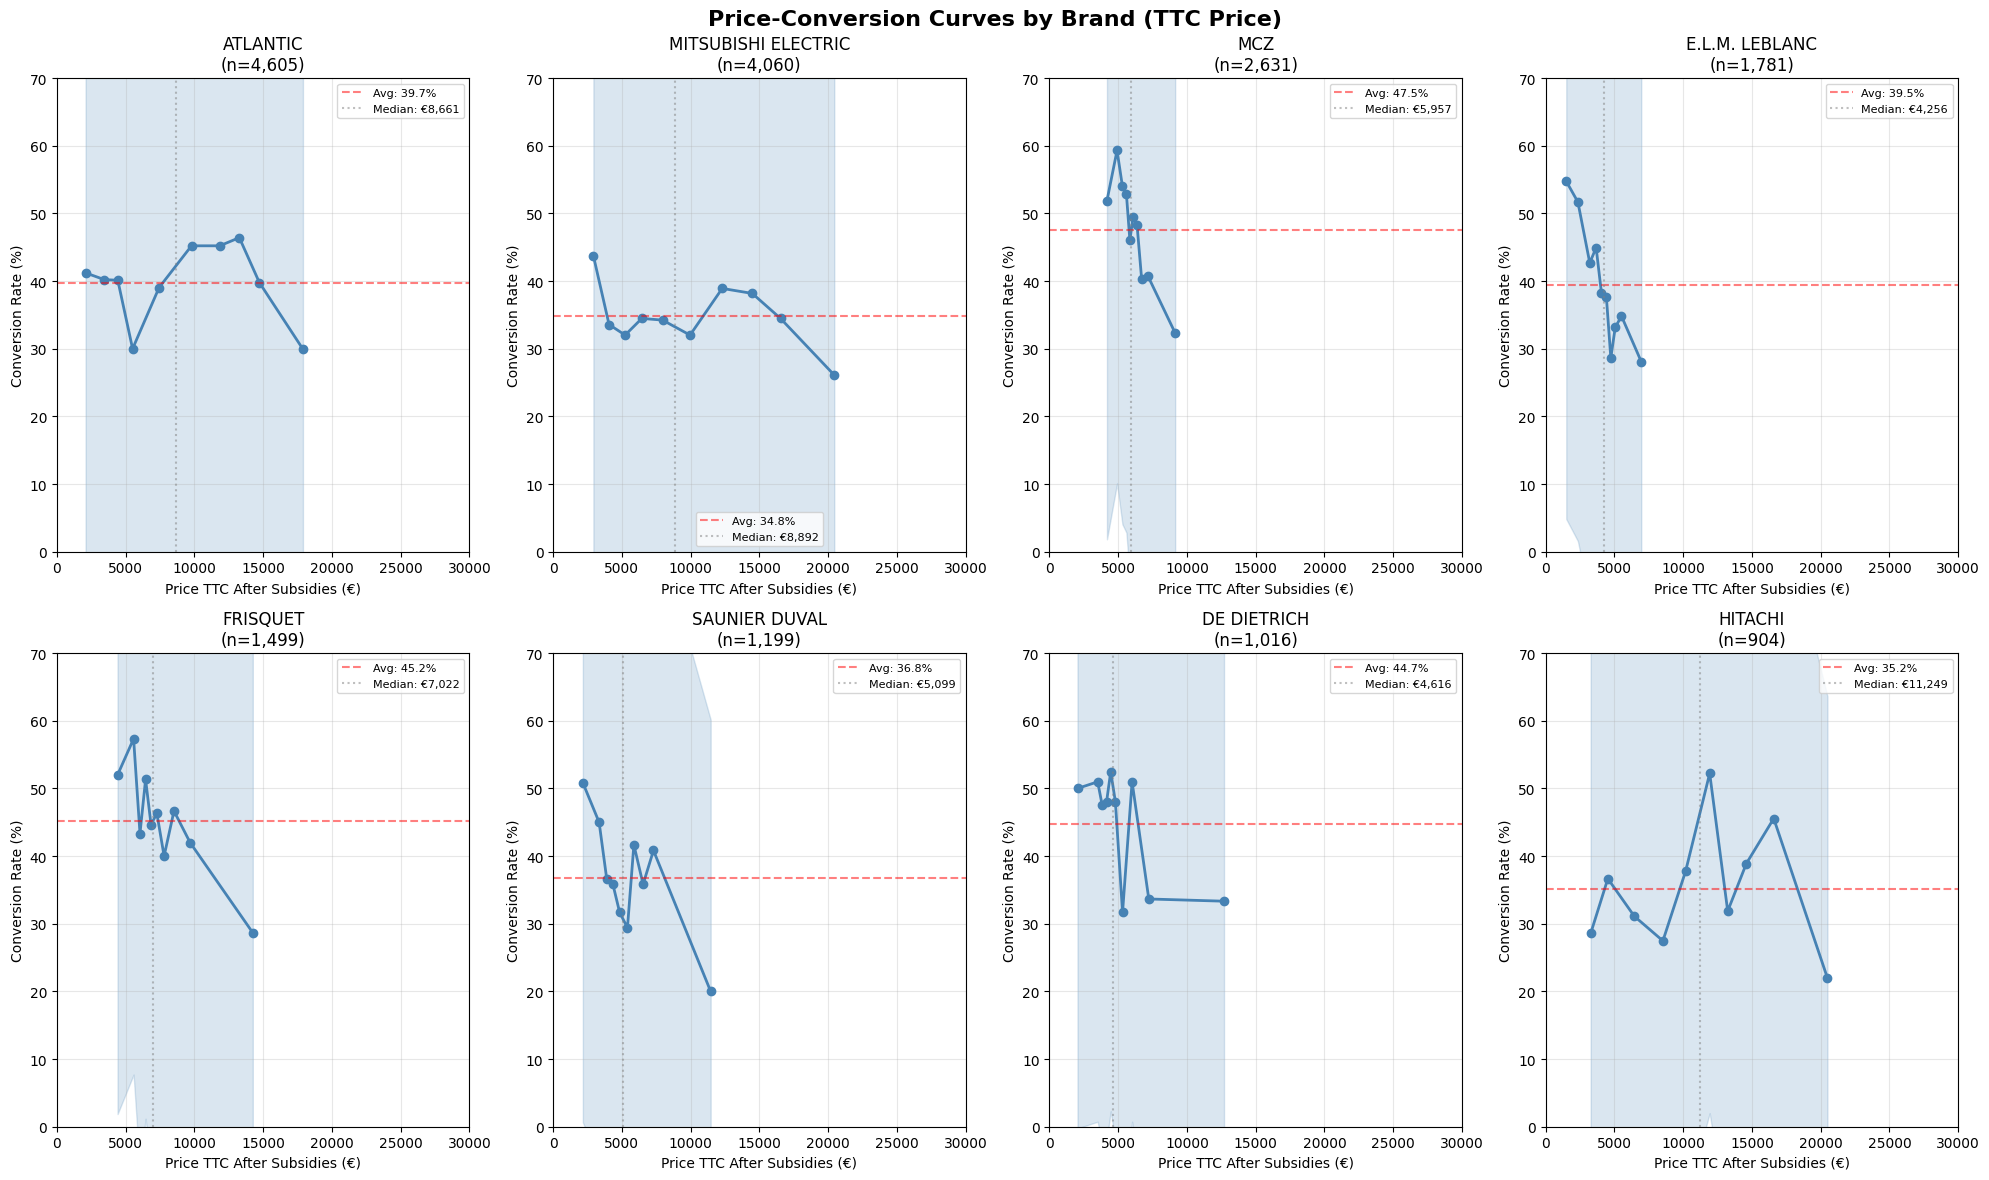


Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309


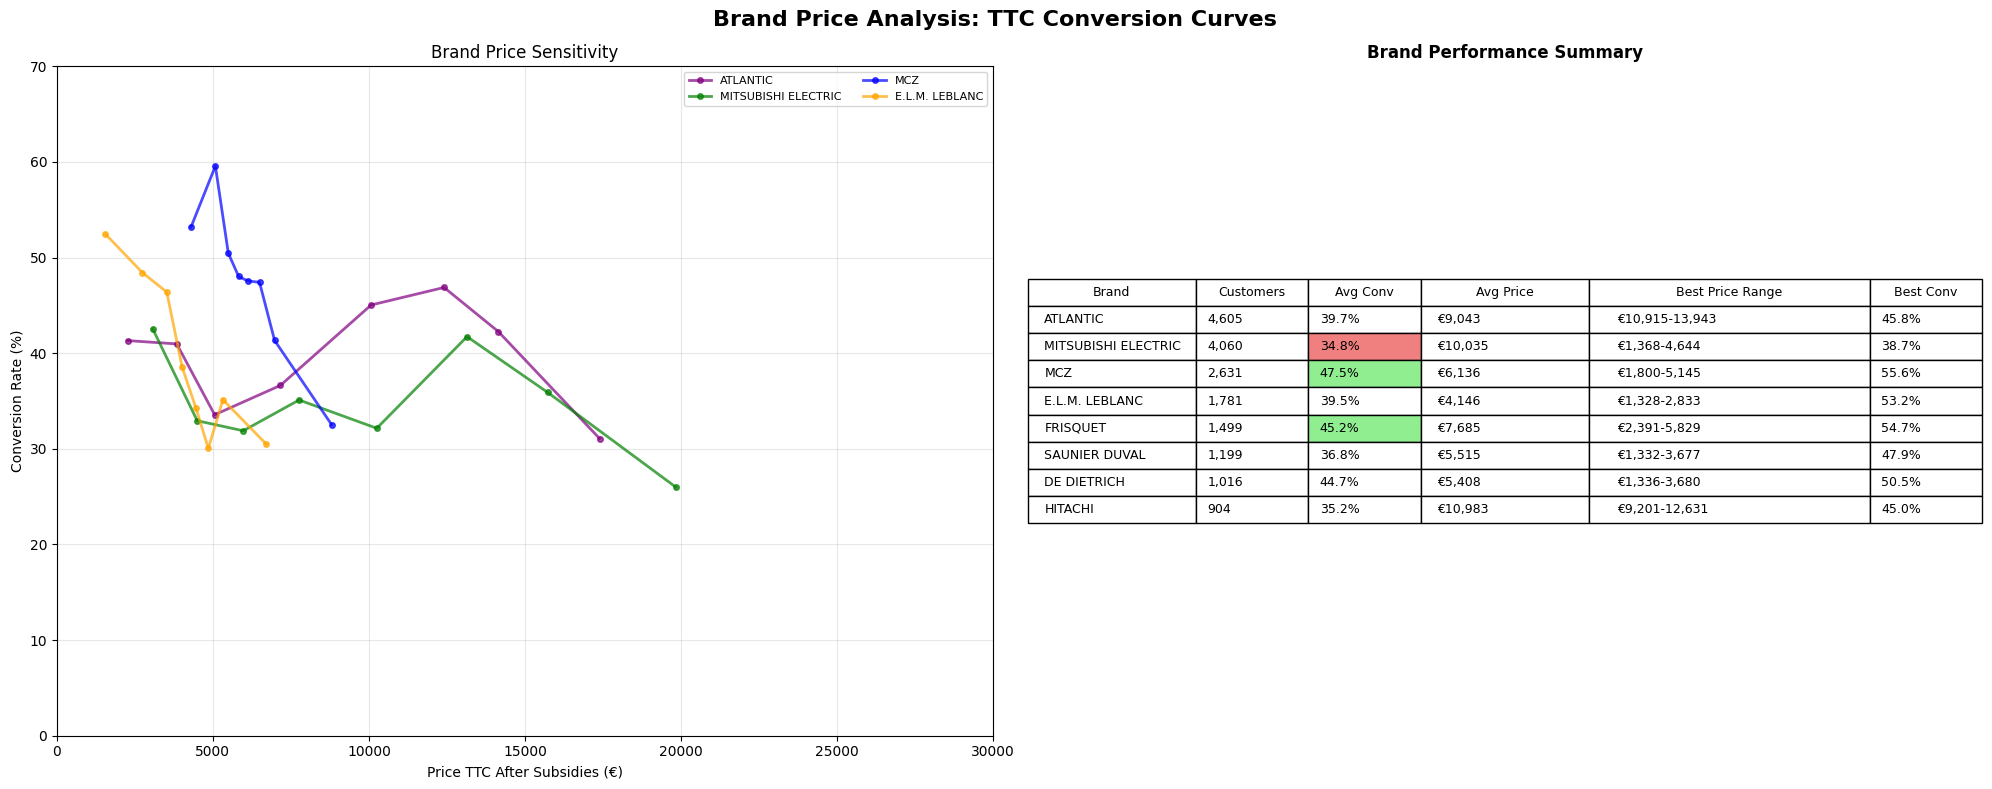


TTC Price-conversion curves: 4 equipment types, multiple brands per graph

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

Heat Pump - Top brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'HITACHI', 'VIESSMANN', 'CHAPPEE']

Boiler - Top brands: ['E.L.M. LEBLANC', 'FRISQUET', 'SAUNIER DUVAL', 'DE DIETRICH', 'ATLANTIC', 'VIESSMANN']

Stove - Top brands: ['MCZ', 'DOVRE', 'JOLLY MEC', 'ORANIER', 'PALAZZETTI', 'Edilkamin']

AC - Top brands: ['MITSUBISHI ELECTRIC', 'ATLANTIC', 'HITACHI', 'DAIKIN', 'BOSCH', 'Unknown']


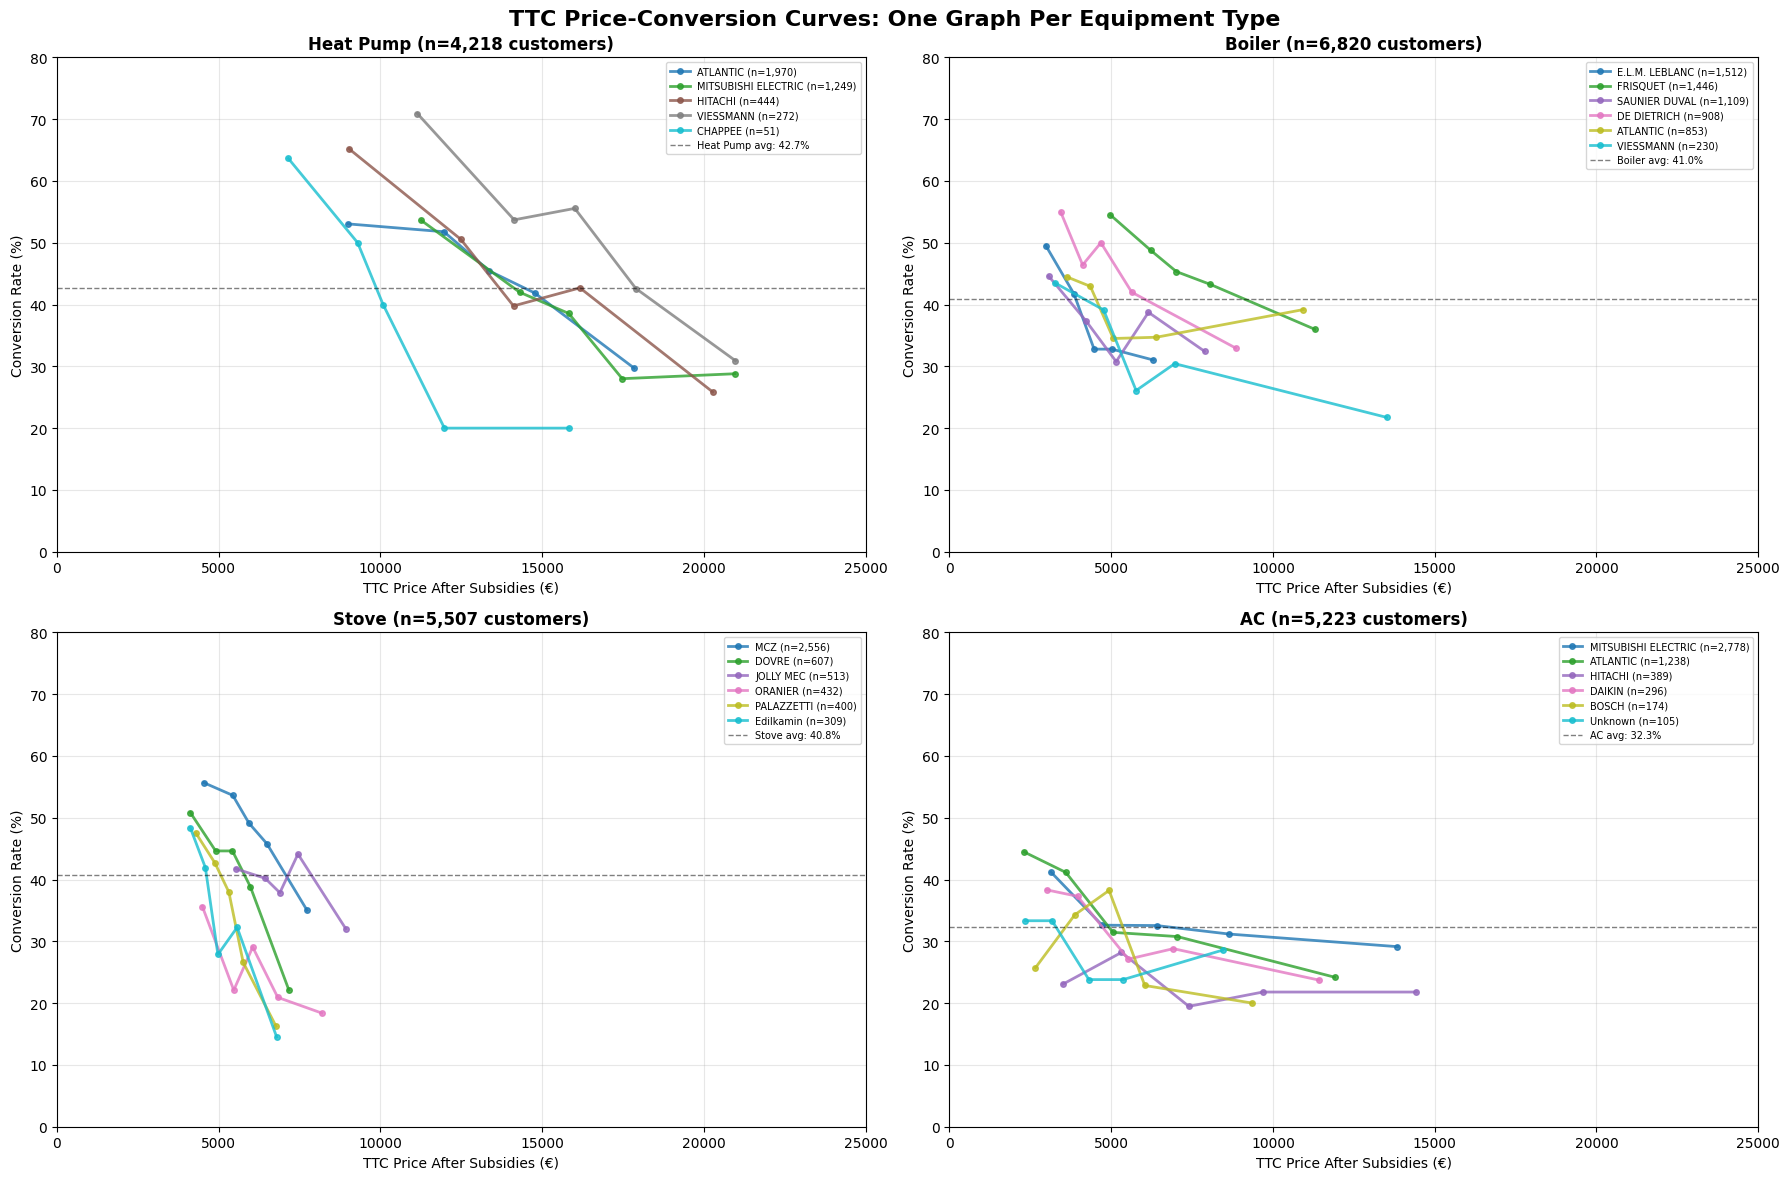


Seasonal Effects on Customer Conversion


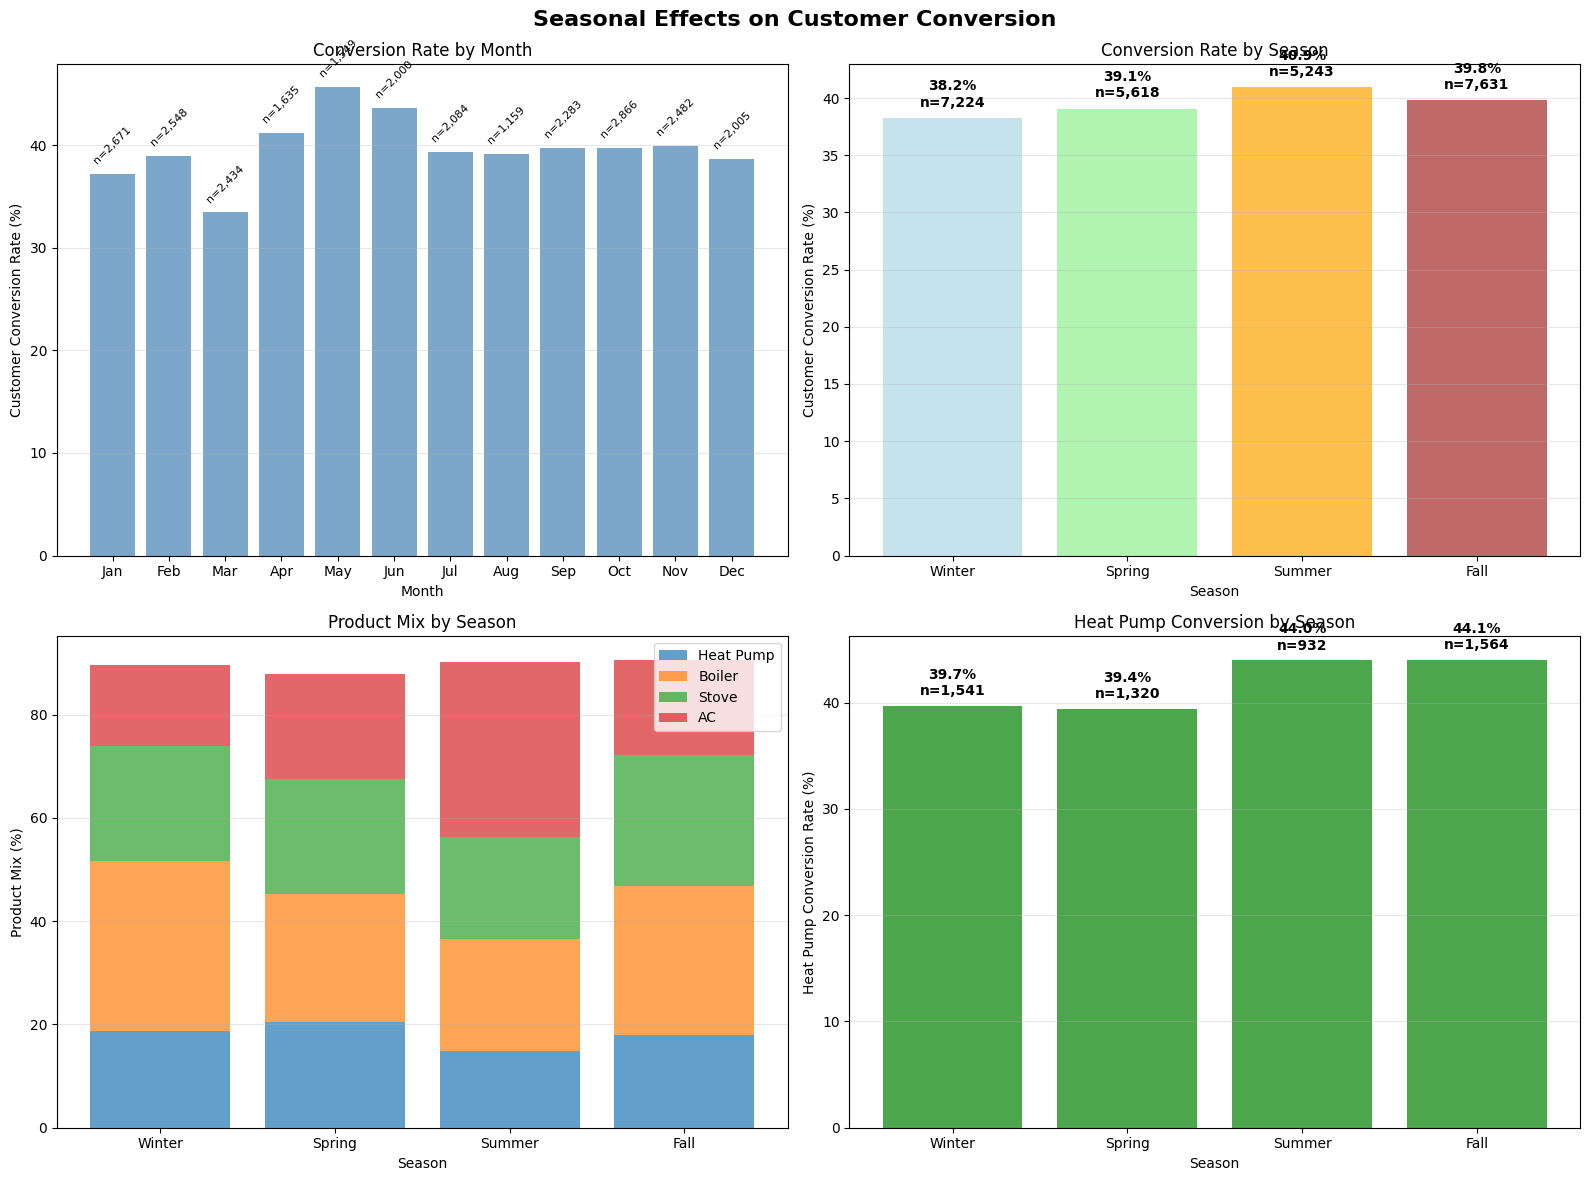


SEASONAL STATISTICS

Conversion by season:
  Winter: 38.2% (n=7,224)
  Spring: 39.1% (n=5,618)
  Summer: 40.9% (n=5,243)
  Fall: 39.8% (n=7,631)

Seasonality chi-square p-value: 0.0193
Statistically significant: YES

Regional Seasonal Pattern

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

Top regions: ['Normandie', 'Auvergne-Rhône-Alpes', 'Île-de-France']


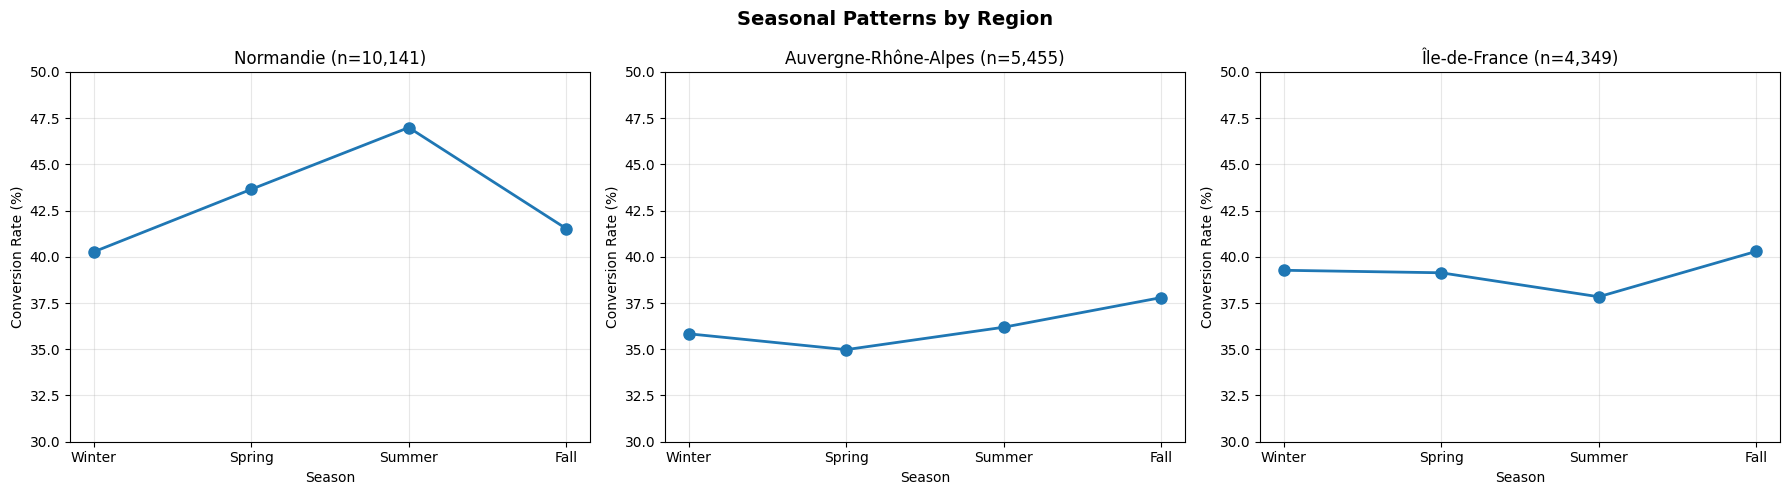


Year-over-year trends

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

Quarterly conversion rates:
                  mean  count
year_quarter                 
2023Q1        0.535294    340
2023Q2        0.479550    978
2023Q3        0.443804   1041
2023Q4        0.407857   1731
2024Q1        0.417211   1685
2024Q2        0.446524   1870
2024Q3        0.406691   1913
2024Q4        0.421484   2560
2025Q1        0.398094   2414
2025Q2        0.405508   2106
2025Q3        0.366539   2349
2025Q4        0.360532   2782
2026Q1        0.264249   2316


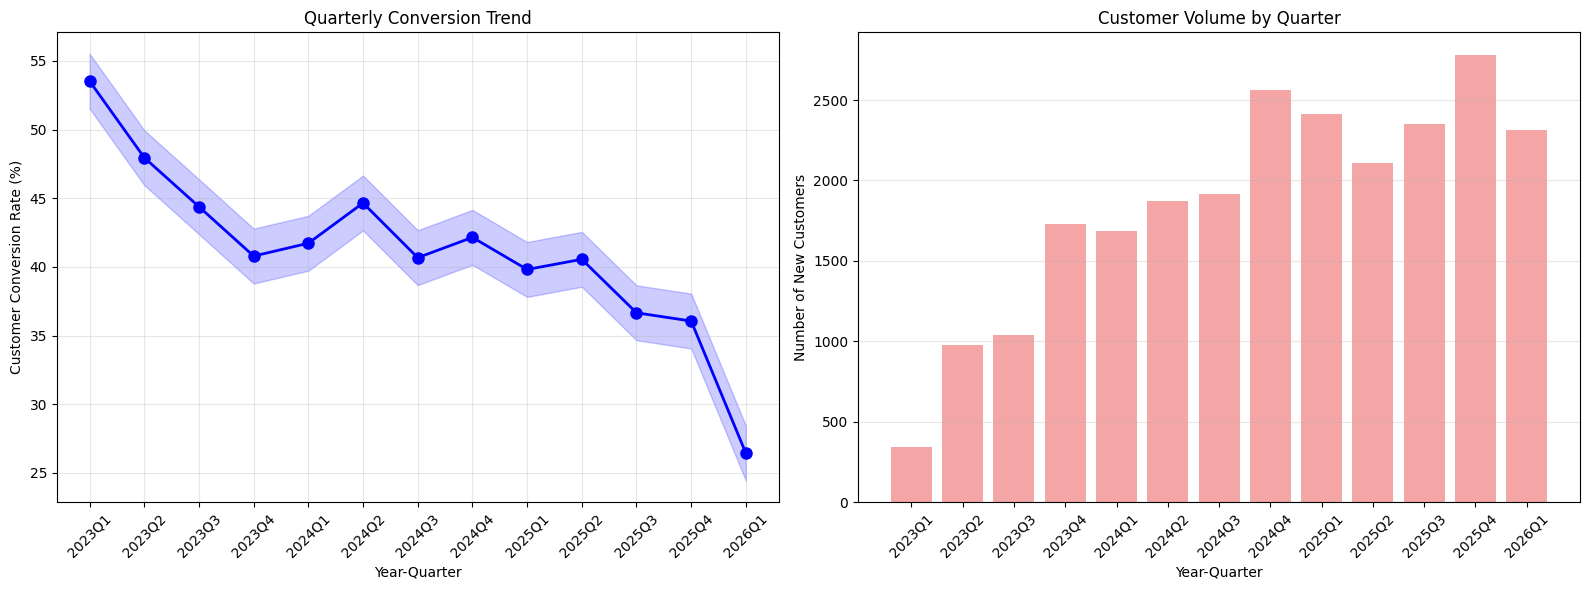


Best and Worst Months Report

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.399886  21126
During Suspension  0.357215   2959

Suspension impact p-value: 0.0000
Statistically significant: YES

Best month: 5 (45.4%, n=1483)
Worst month: 3 (33.4%, n=2195)

Best season: Summer (41.2%)
Worst season: Winter (38.1%)

Heat pump conversion by season:
  Winter: 40.9%
  Spring: 40.4%
  Summer: 45.7%
  Fall: 44.7%

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309


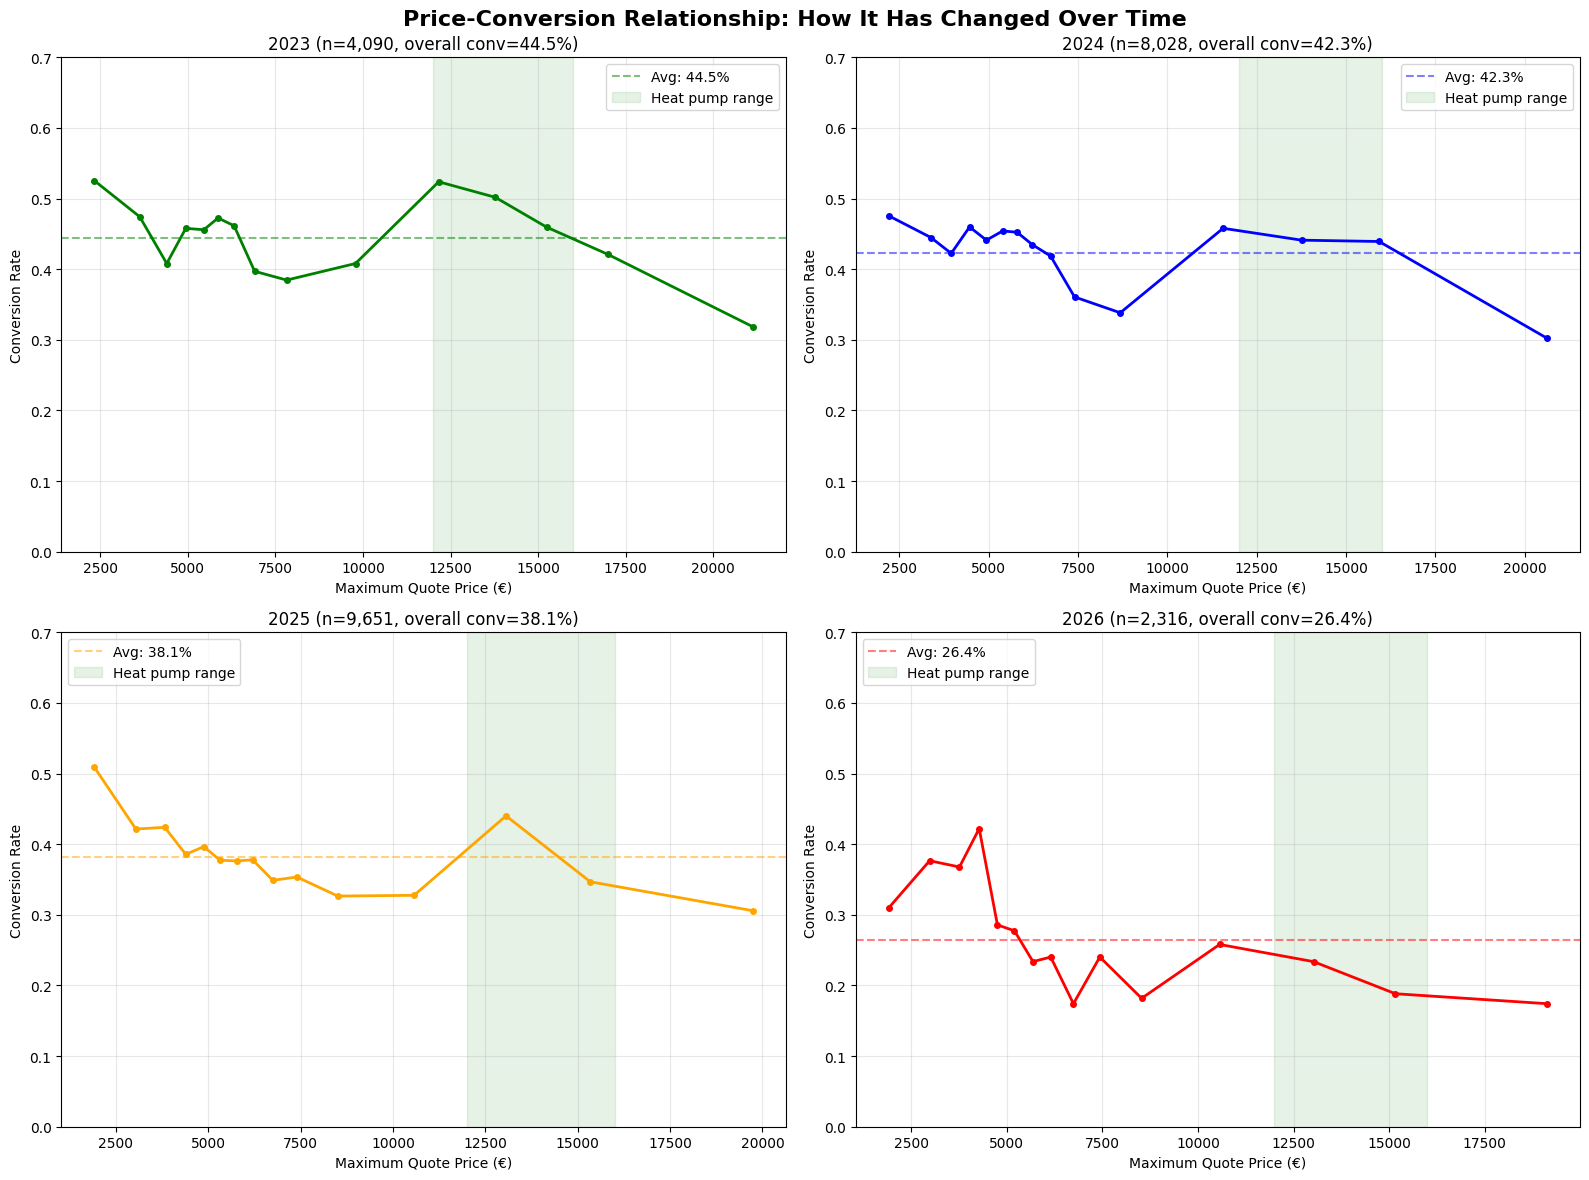


Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309


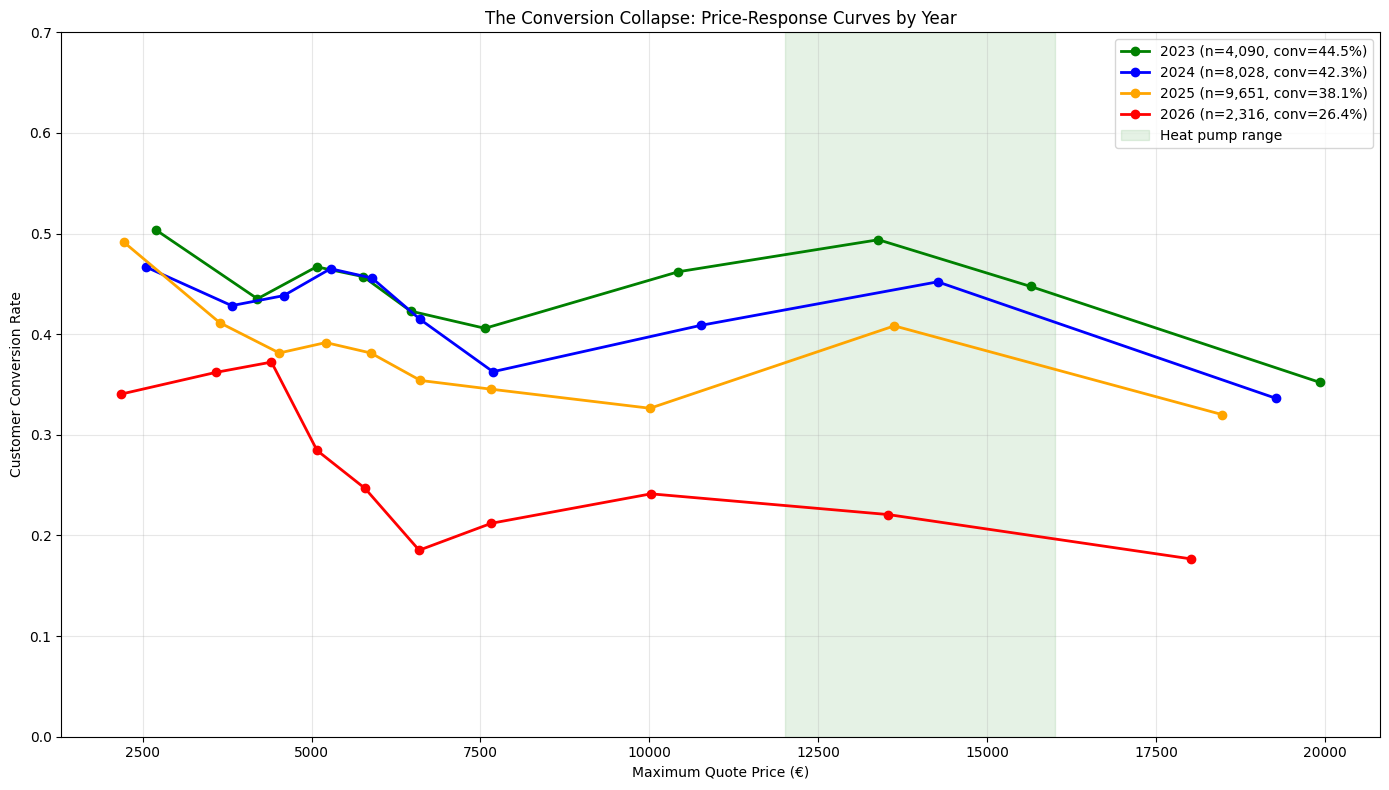


Sweet Spot Analysis Over Time

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

Sweet spots by year (price points with conversion > avg + 3%):

2023 (overall avg: 44.5%):
  €2,062: 54.1% (n=205)
  €3,920: 48.1% (n=210)
  €11,413: 50.7% (n=205)
  €12,812: 49.0% (n=204)
  €13,965: 49.8% (n=205)

2024 (overall avg: 42.3%):
  €1,970: 49.5% (n=402)
  €5,115: 49.4% (n=401)
  €6,043: 47.1% (n=401)
  €11,976: 48.6% (n=401)
  €15,010: 49.0% (n=402)

2025 (overall avg: 38.1%):
  €1,750: 52.4% (n=483)
  €2,684: 46.0% (n=483)
  €3,902: 43.1% (n=483)
  €5,043: 42.1% (n=482)
  €12,793: 43.6% (n=482)


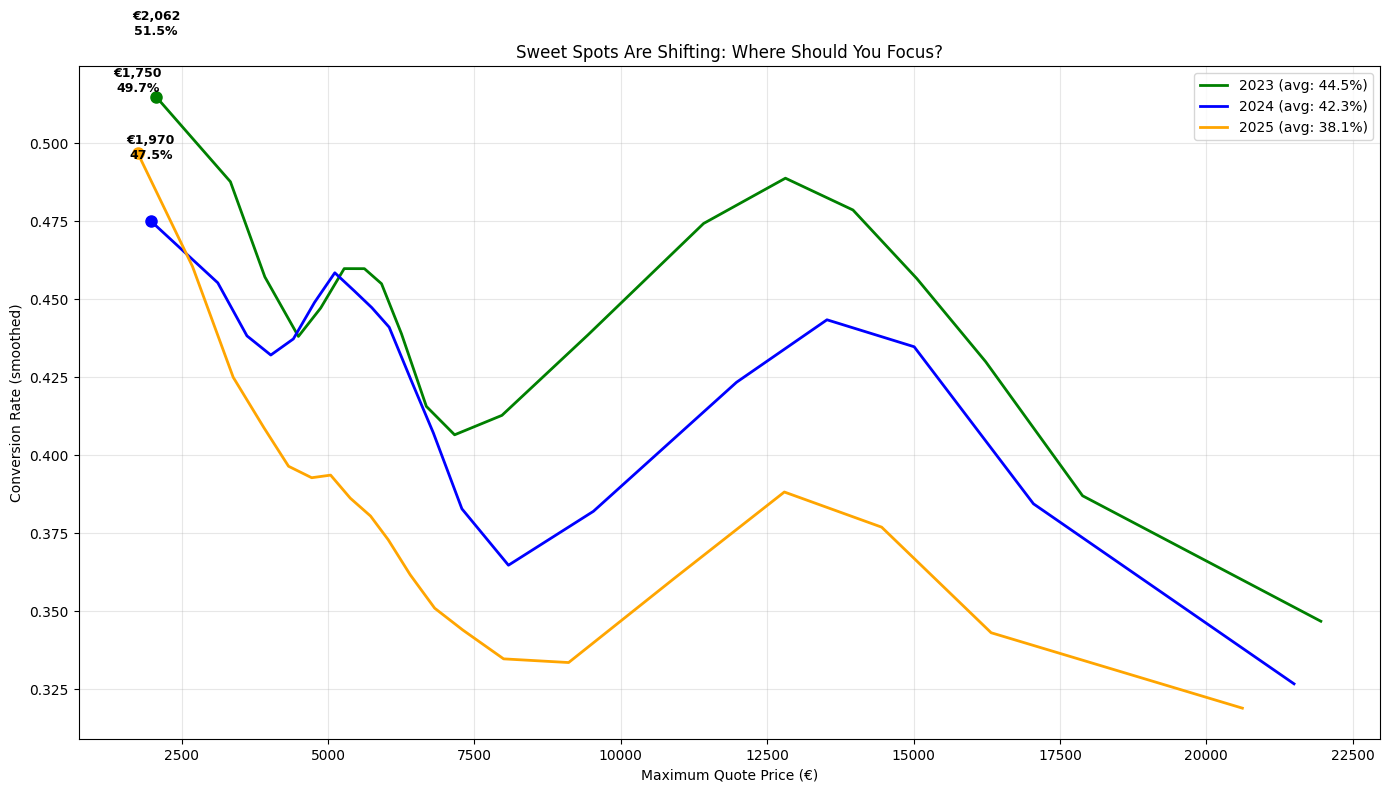


Administrative Uncertainty Effect

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

Decision time distribution:
count    24085.000000
mean        21.708034
std         91.365934
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       1085.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 19,968 (82.9%)


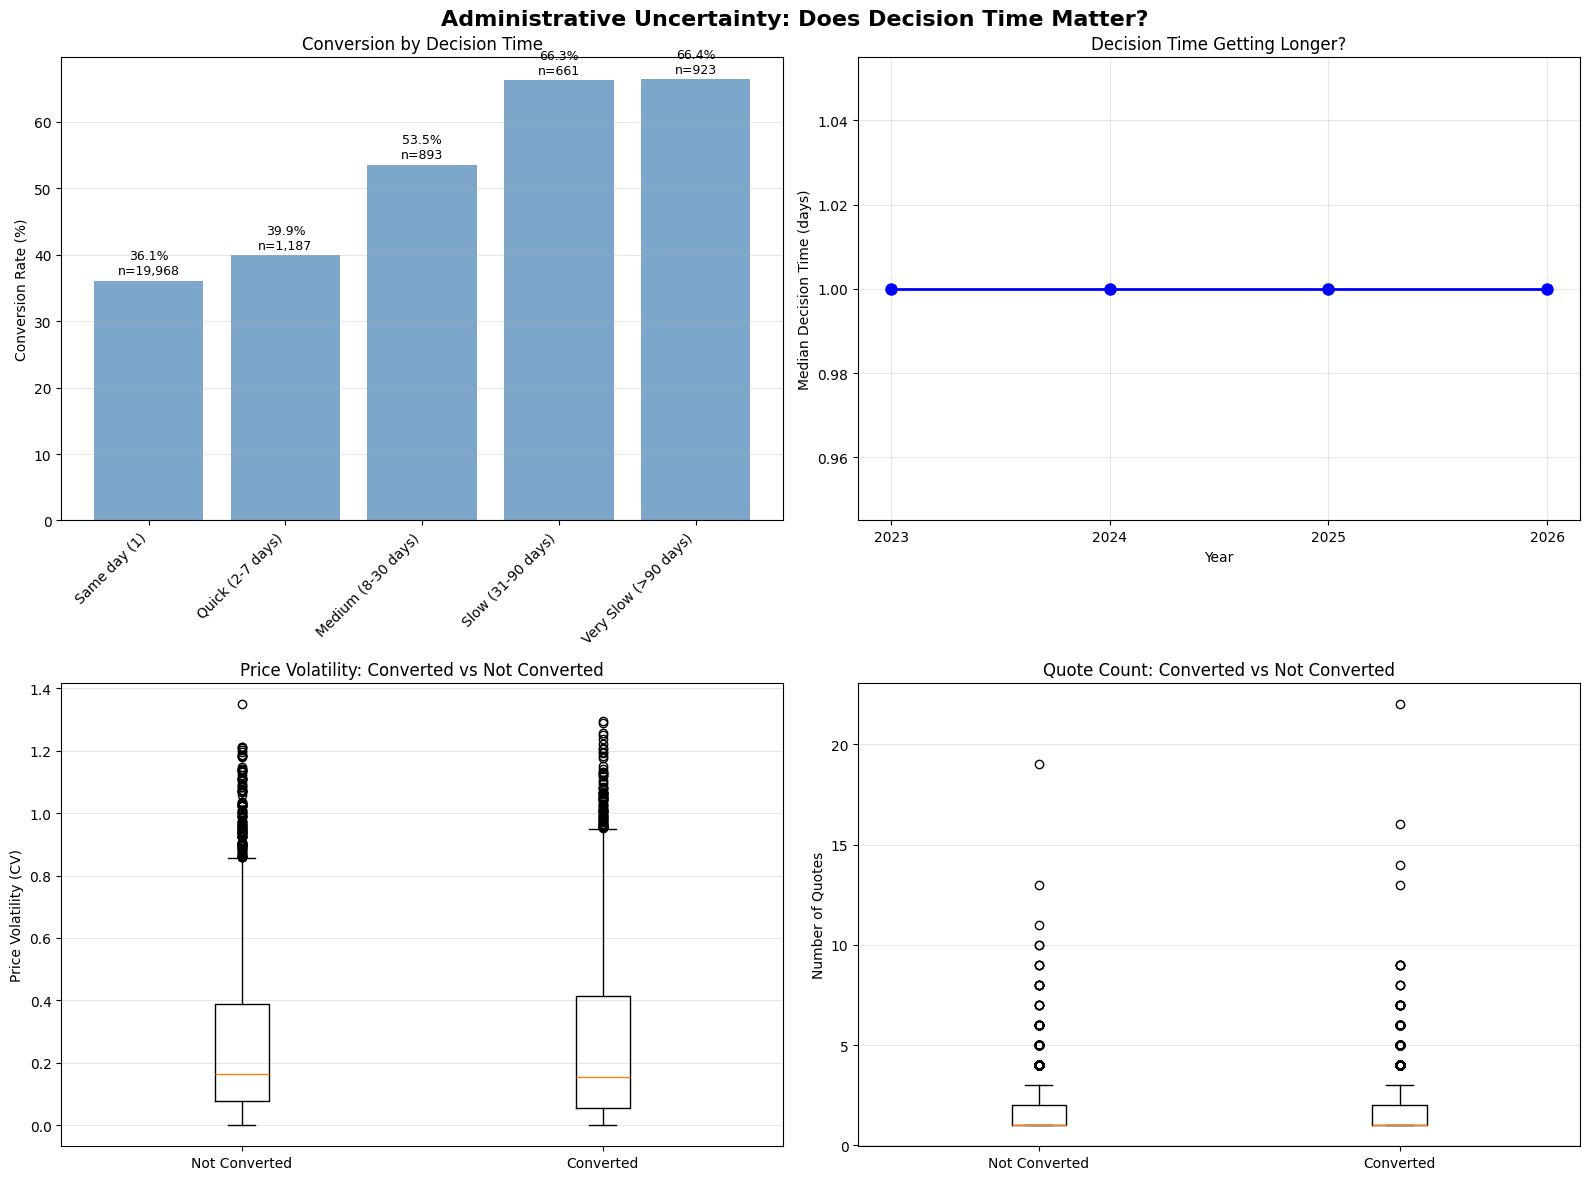


Product Type - Price Conversion Heatmap
Simple pivot table:
price_bin_simple         (1086.579, 4176.528]  (4176.528, 5642.004]  \
main_equipment_category                                               
AC                                  37.839879             32.461356   
Boiler                              46.158068             38.014888   
Heat Pump                           45.945946             86.363636   
Other                               48.797251             45.398773   
Stove                               50.180505             46.744931   

price_bin_simple         (5642.004, 7202.244]  (7202.244, 12997.88]  \
main_equipment_category                                               
AC                                  29.751131             28.793774   
Boiler                              43.175487             37.415541   
Heat Pump                           36.363636             54.205607   
Other                               50.909091             29.216867   
Stove          

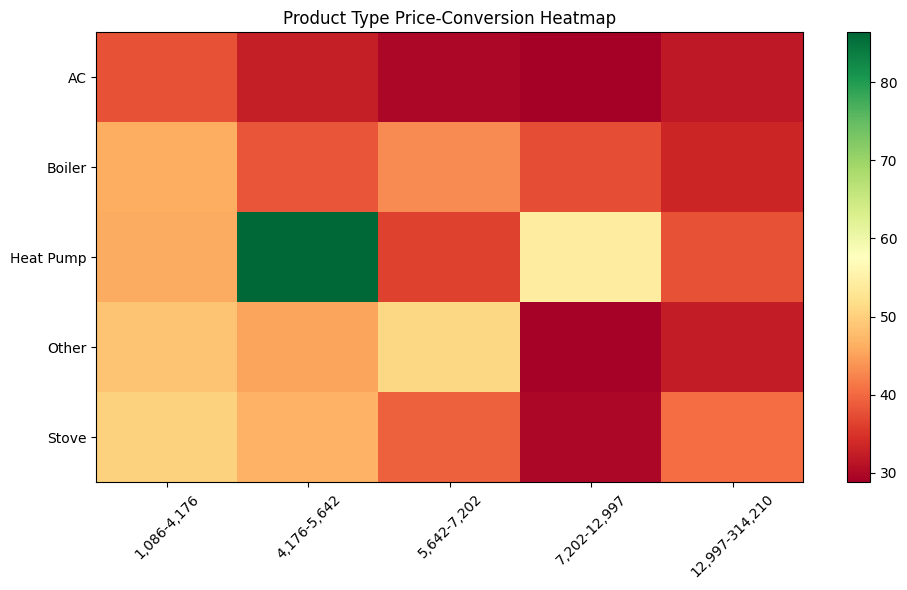


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           7127
Poêle                               5838
Climatisation                       5342
Pompe à chaleur                     4322
ECS : Chauffe-eau ou adoucisseur    1386
Photovoltaïque                       645
Emetteur de chauffage  ou chappe     310
Autres                               279
Unknown                              168
Appareil hybride                     157
Accessoire de pose                    70
Produit VMC                           58
Plomberie Sanitaire                   13
Régulation ou électricité              1
Name: count, dtype: int64

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309


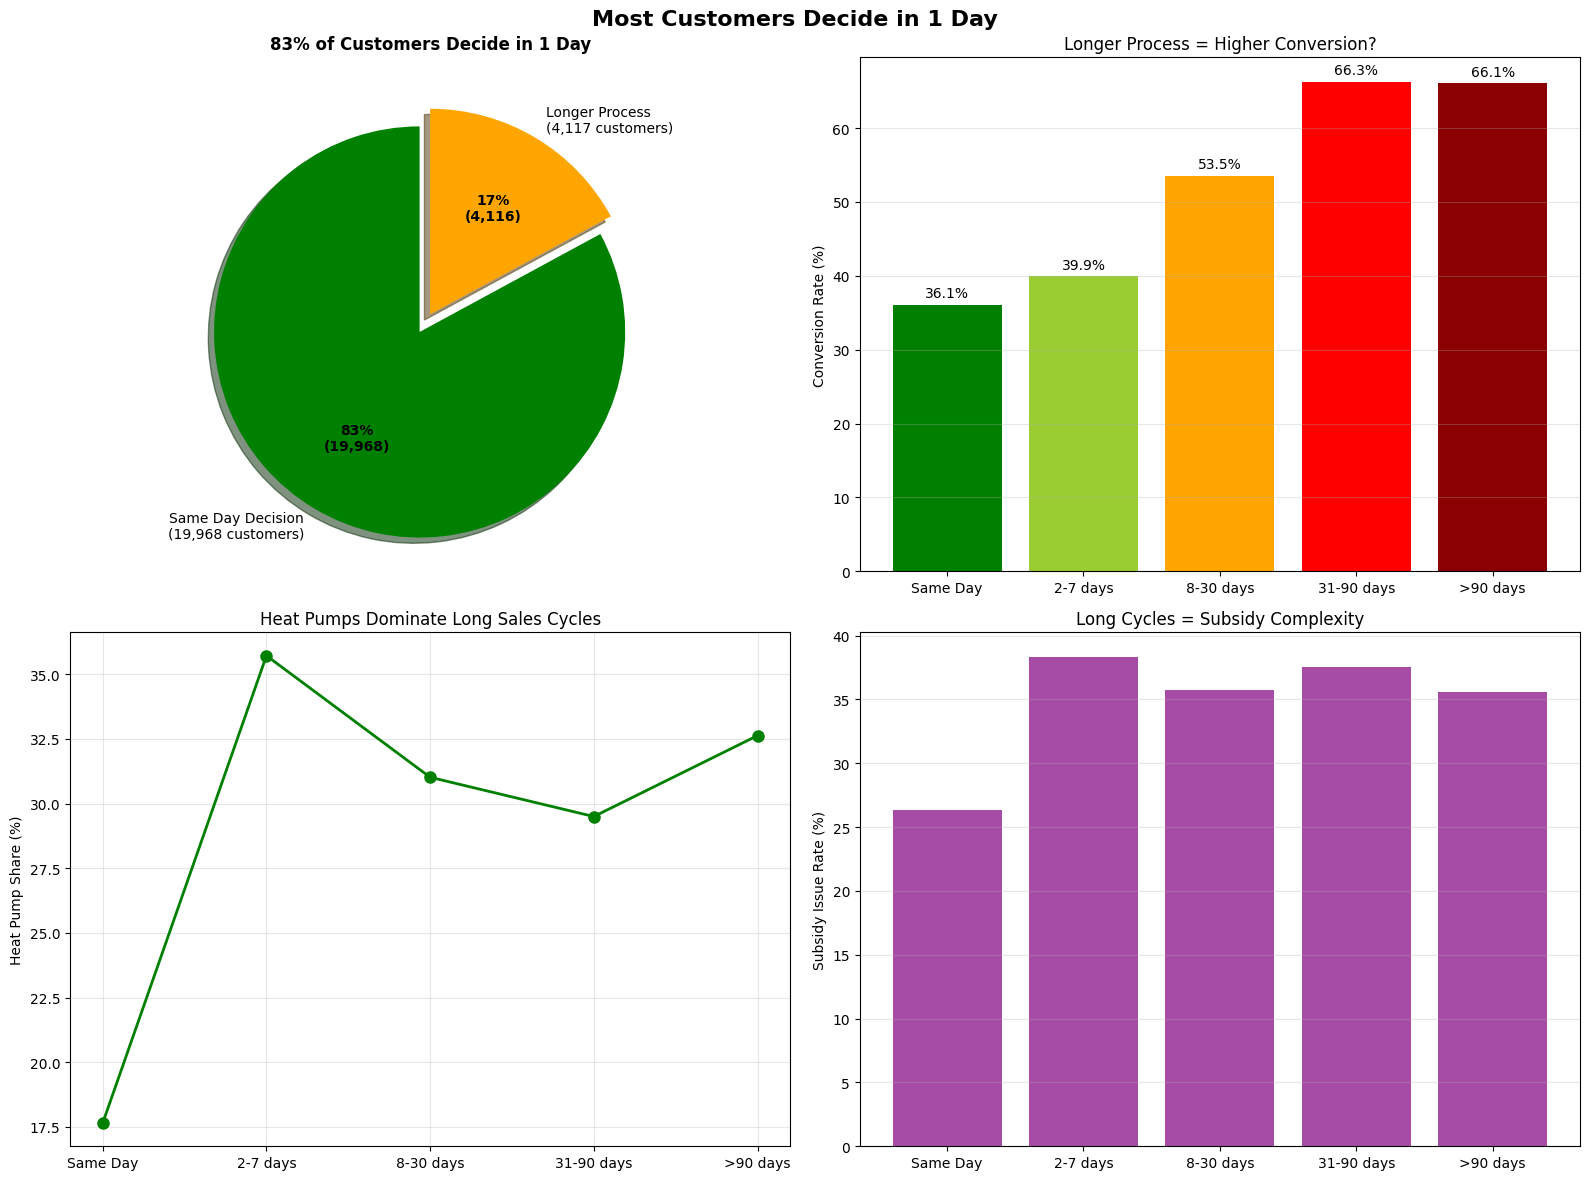


Heat Pump Performance Over Time

Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2023              0.481            1281  15331.030               0.732
2024              0.450            1557  15538.494               0.680
2025              0.415            1605  15290.053               0.753
2026              0.234             427  15032.380               0.773


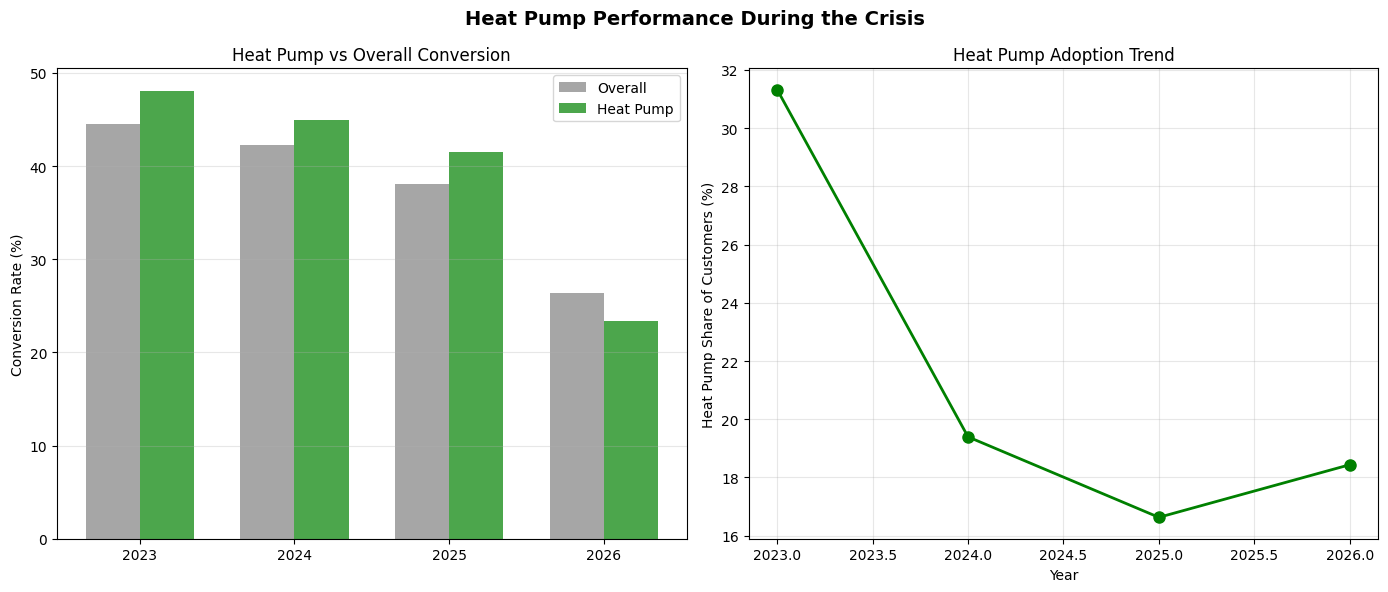


Analyzing 24,085 customers
Price range: €1,332 to €28,168
Median price: €6,309

DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €1.6k (48.9%) and €2.5k (47.9%)
Dead zone: €19.4k-28.2k (29-36%)
Heat pumps: 73% subsidy issues, 42.8% conversion
Price sensitivity: Heat Pump (23.0pts) > Stove (16.3pts) > Boiler (9.4pts) > AC (7.6pts)
Same day decisions: 83%


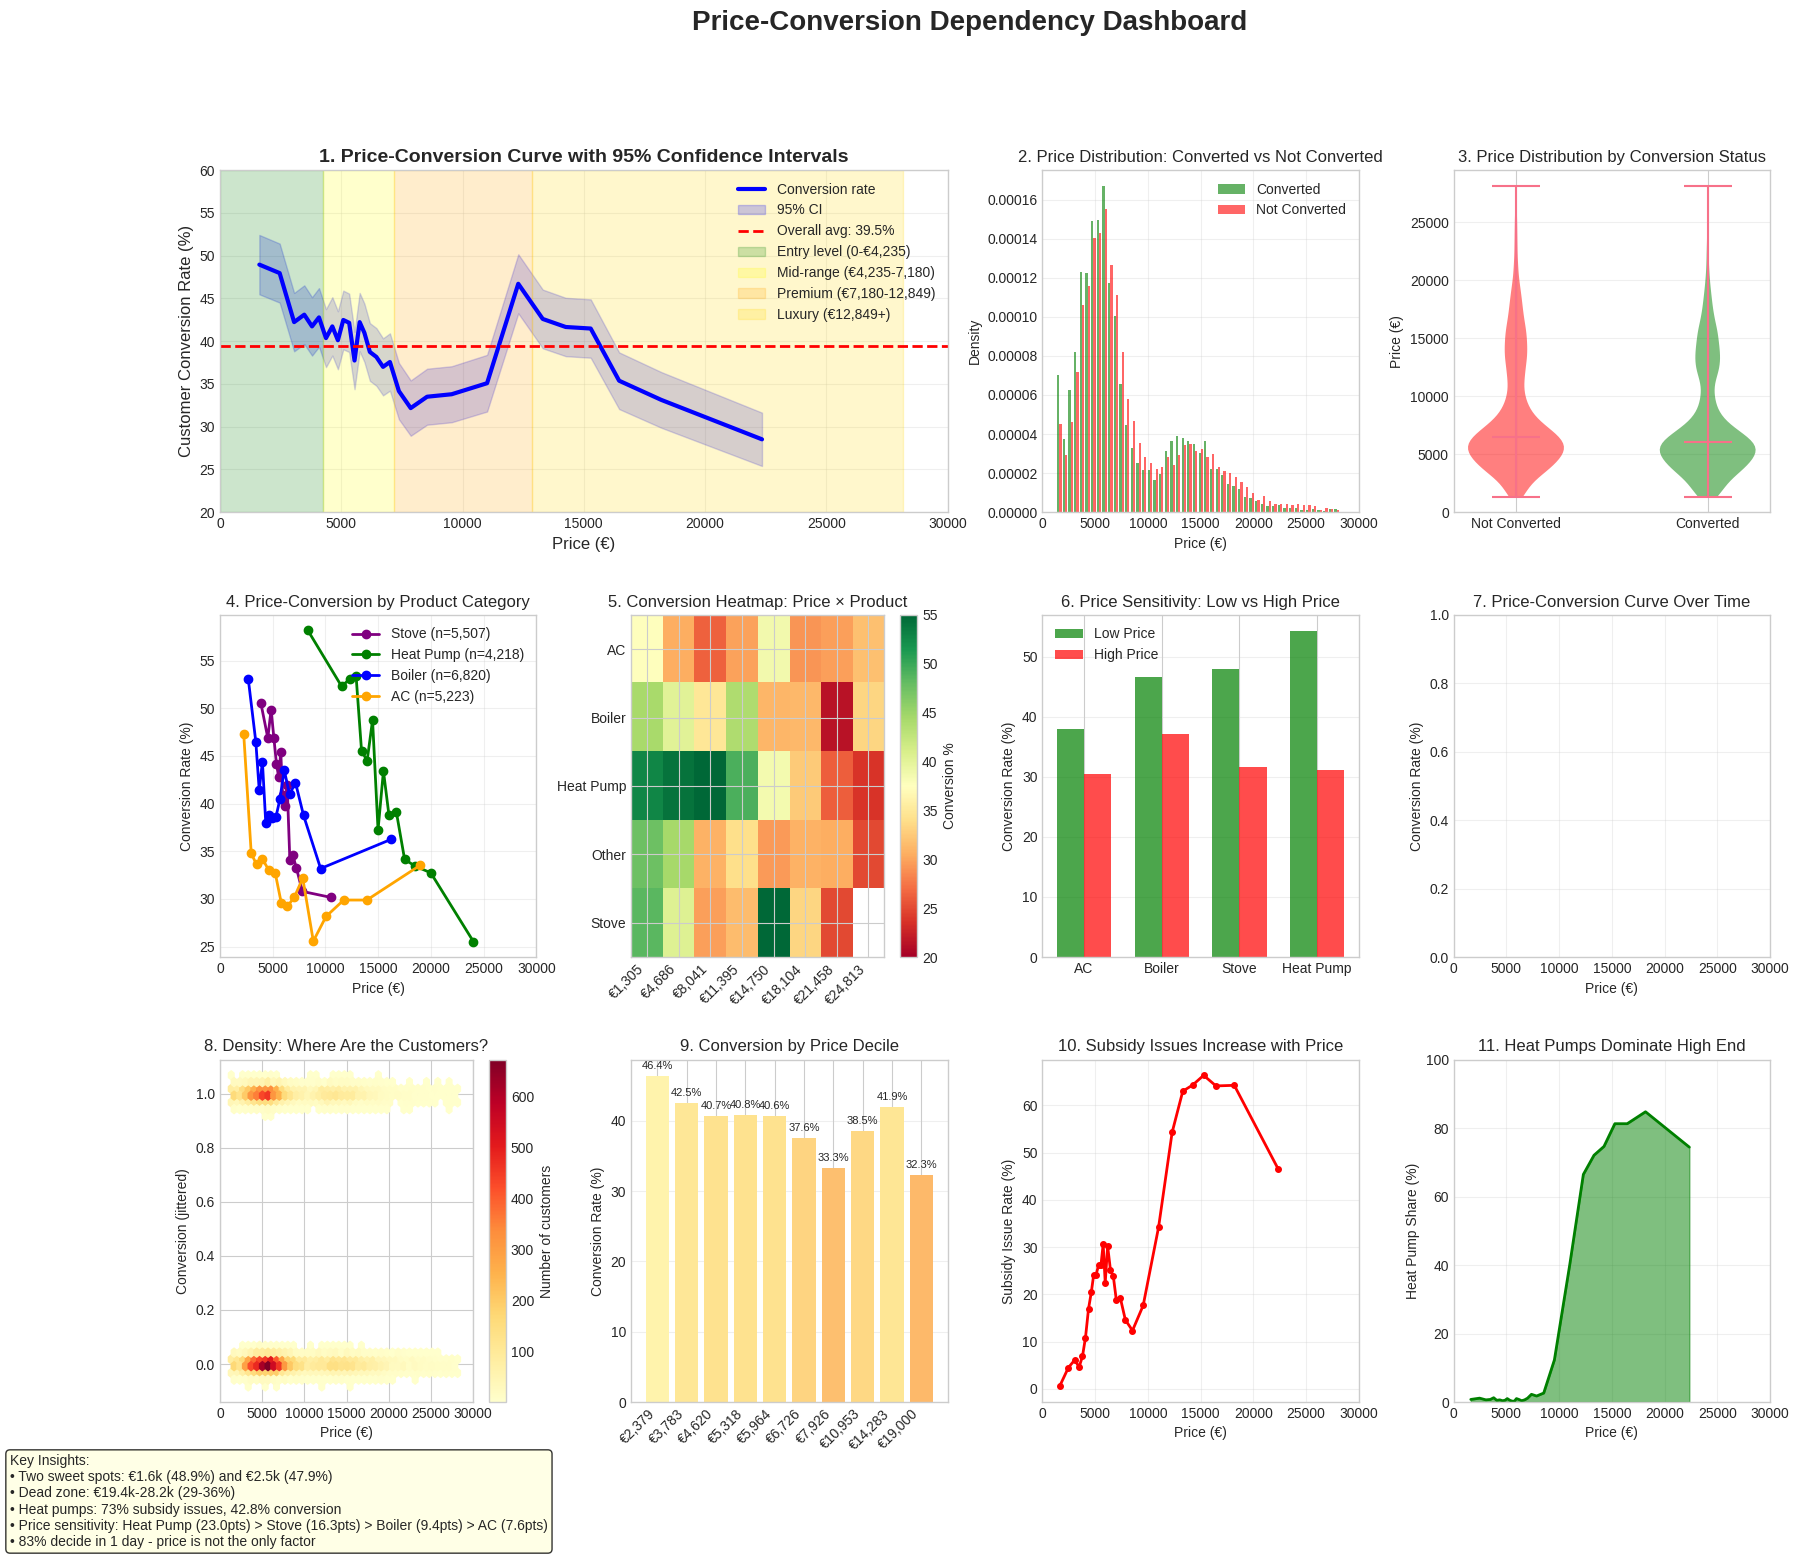

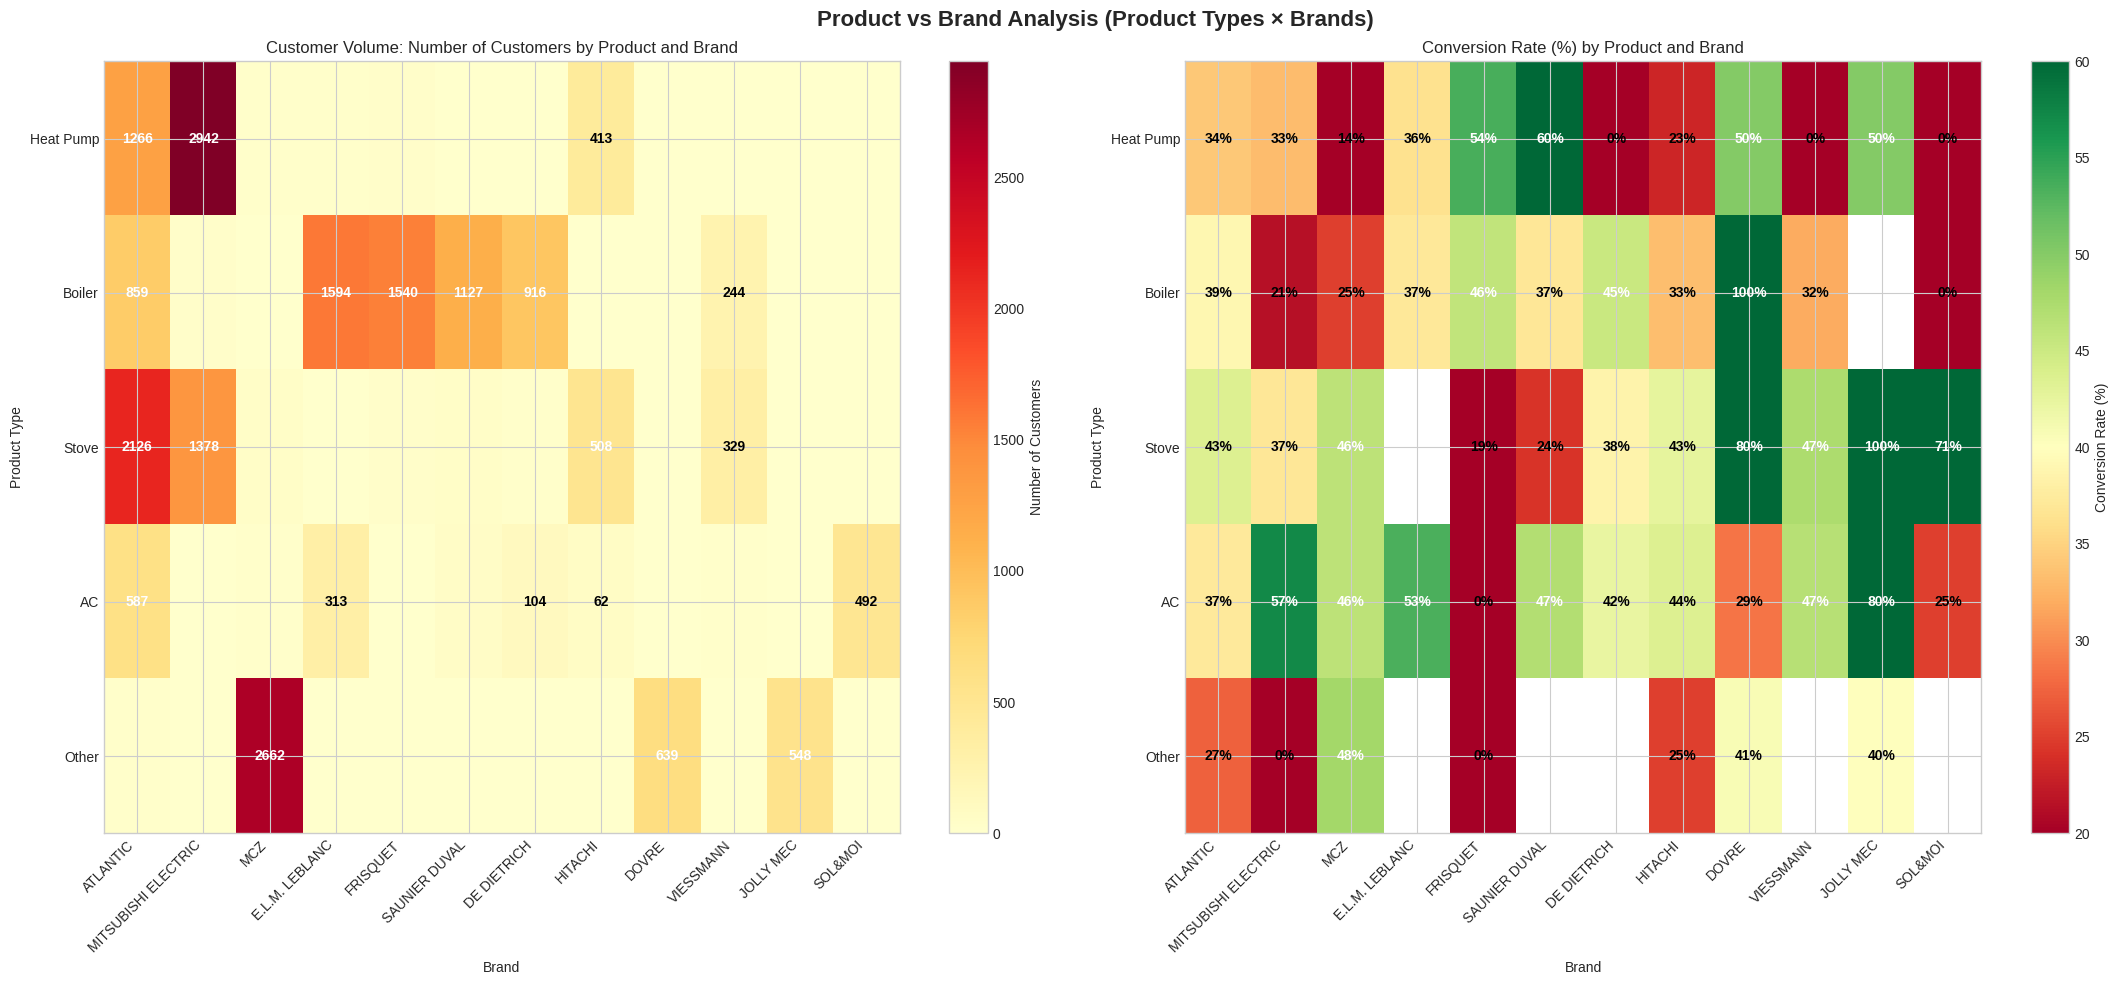


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC   MCZ  E.L.M. LEBLANC  FRISQUET  SAUNIER DUVAL  DE DIETRICH  HITACHI  DOVRE  VIESSMANN  JOLLY MEC  SOL&MOI
main_equipment_category                                                                                                                                          
AC                           1266                 2942    21              22        28             10            4      413      4          3          2        1
Boiler                        859                   28     4            1594      1540           1127          916        6      1        244          0        1
Heat Pump                    2126                 1378    39               0        31             37           13      508     10        329          1        7
Other                         587        

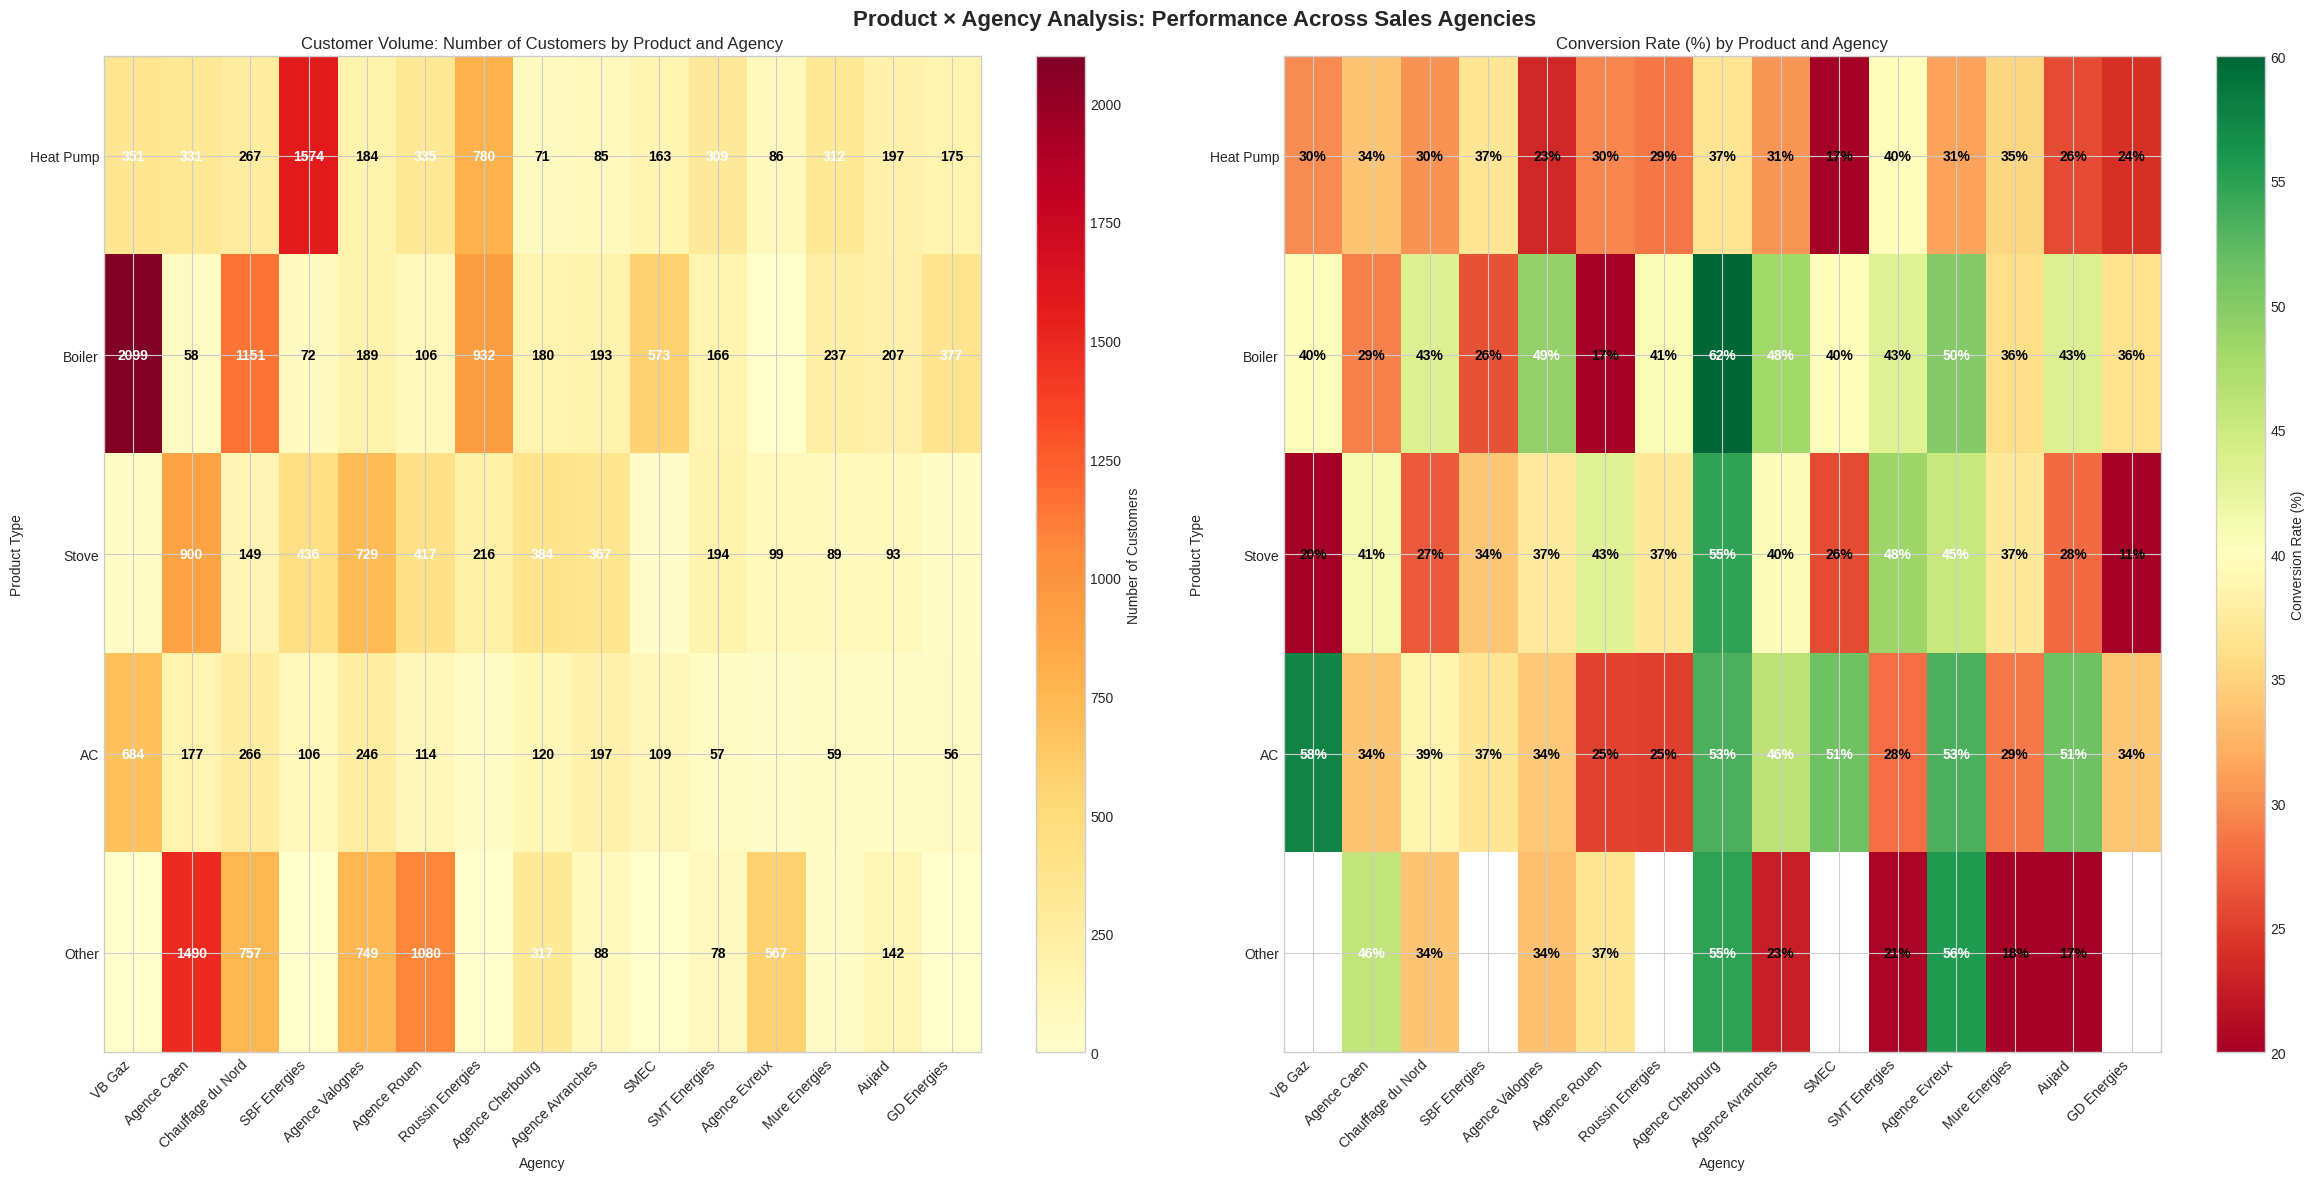


PRODUCT × AGENCY ANALYSIS

📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:
----------------------------------------------------------------------------------------------------
main_agency              VB Gaz  Agence Caen  Chauffage du Nord  SBF Energies  Agence Valognes  Agence Rouen  Roussin Energies  Agence Cherbourg  Agence Avranches  SMEC  SMT Energies  Agence Evreux  Mure Energies  Aujard  GD Energies
main_equipment_category                                                                                                                                                                                                                  
AC                          351          331                267          1574              184           335               780                71                85   163           309             86            312     197          175
Boiler                     2099           58               1151            72              189           106               932  

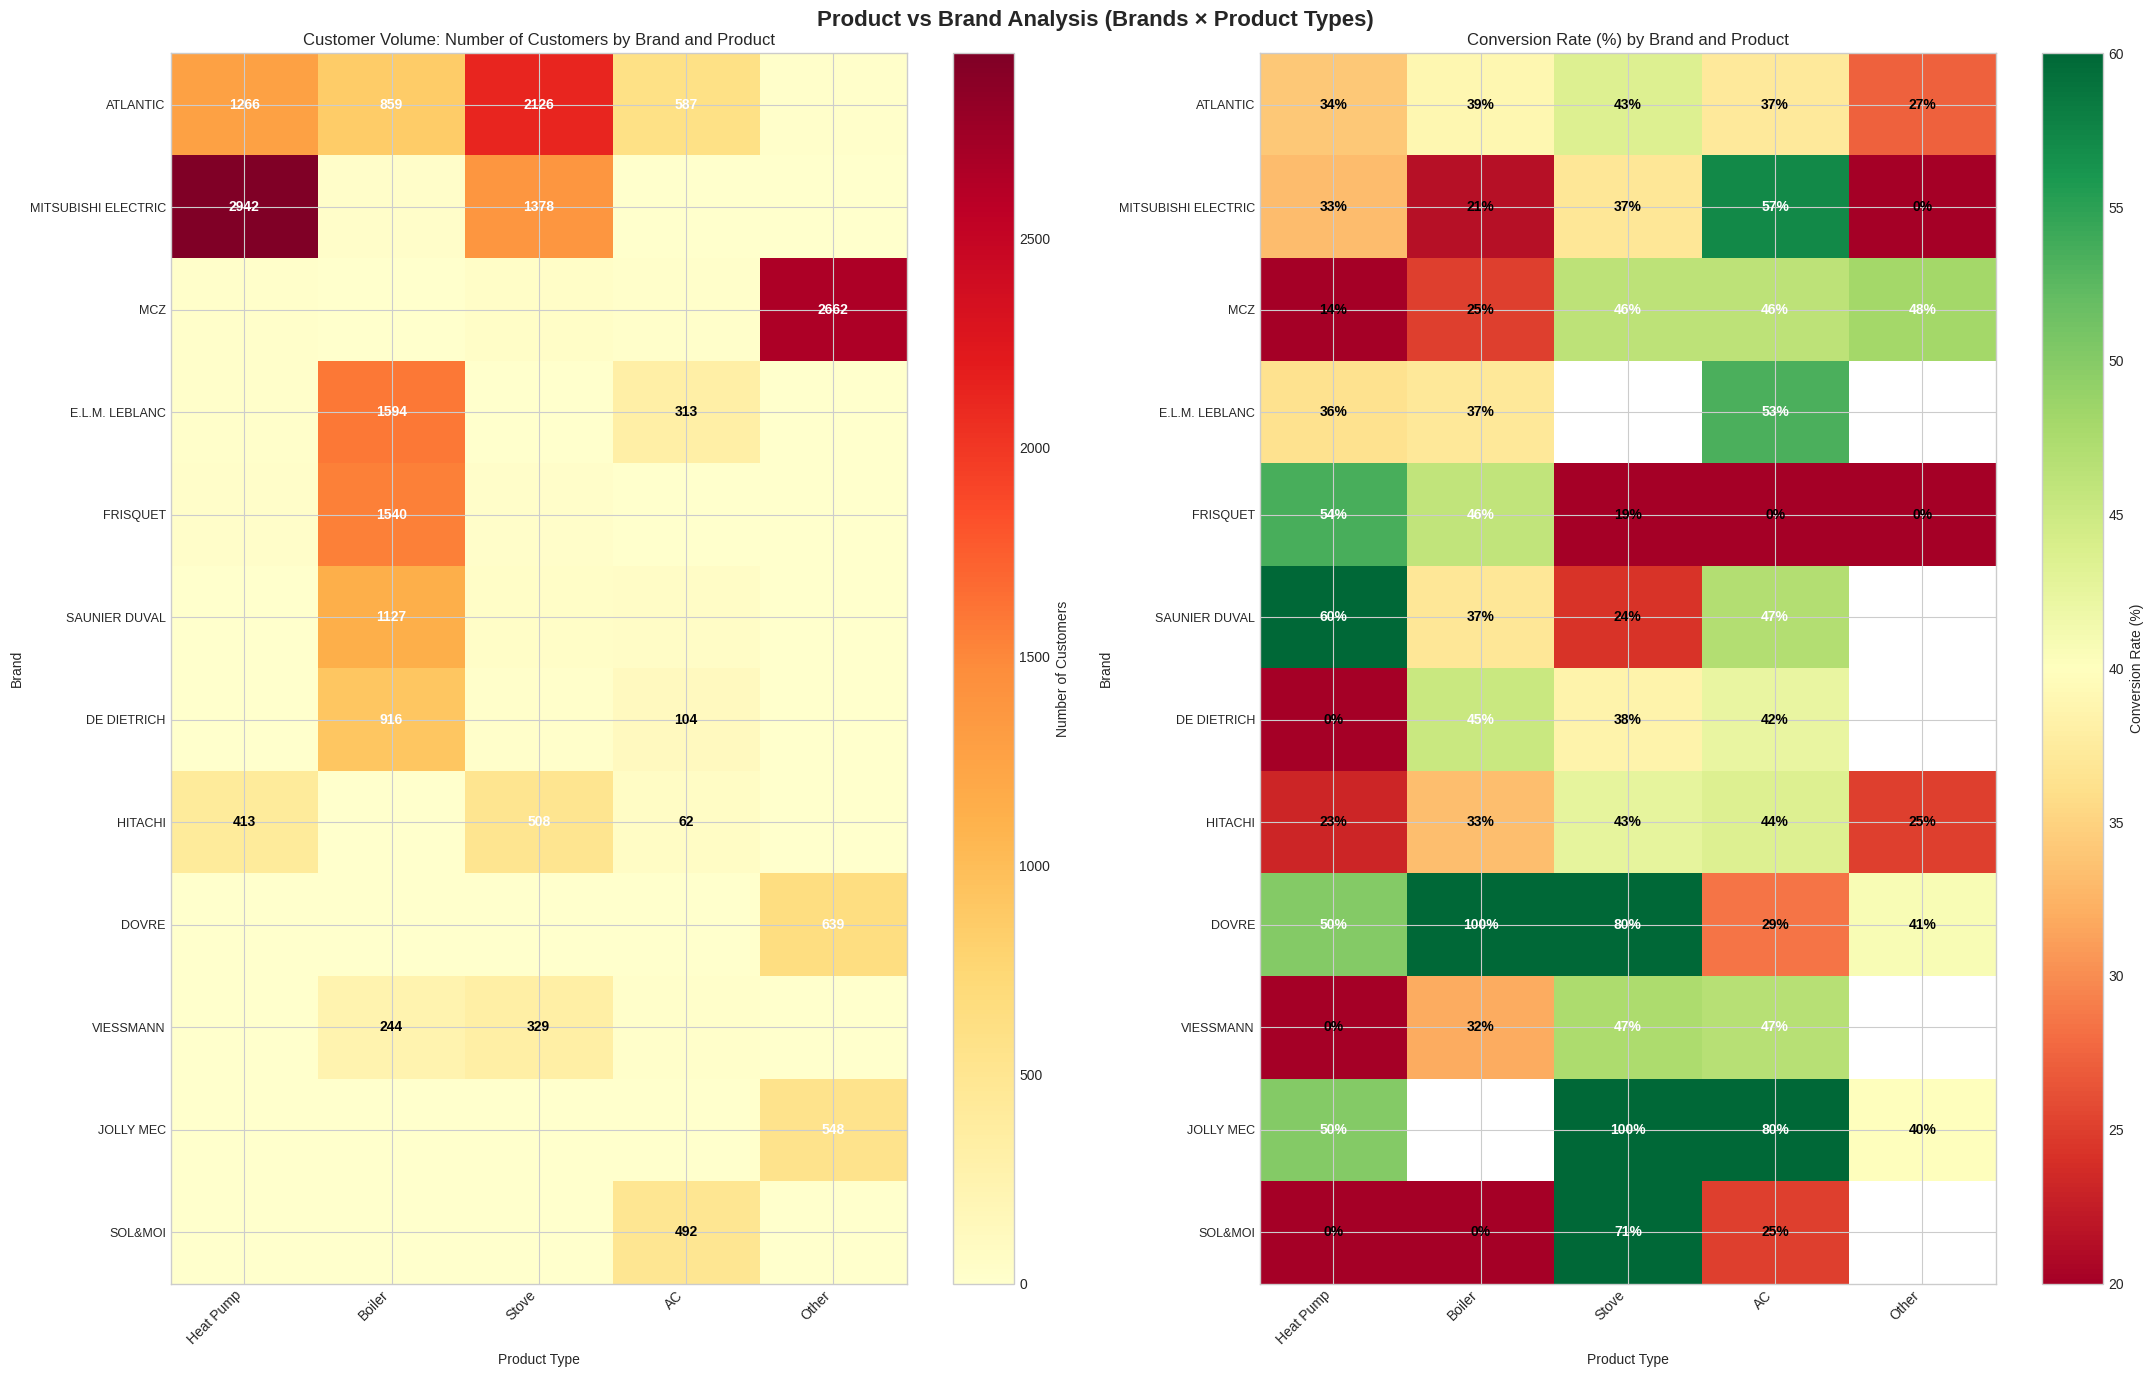


BRAND × PRODUCT ANALYSIS (Swapped Axes)

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
main_brand                                                    
ATLANTIC                 1266     859       2126    587     22
MITSUBISHI ELECTRIC      2942      28       1378      7      1
MCZ                        21       4         39     13   2662
E.L.M. LEBLANC             22    1594          0    313      0
FRISQUET                   28    1540         31      1      1
SAUNIER DUVAL              10    1127         37     49      0
DE DIETRICH                 4     916         13    104      0
HITACHI                   413       6        508     62      4
DOVRE                       4       1         10      7    639
VIESSMANN                   3     244        329     15      0
JOLLY MEC                   2       0          1      5    548
SOL&MOI          

(main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
 main_brand                                                    
 ATLANTIC                 1266     859       2126    587     22
 MITSUBISHI ELECTRIC      2942      28       1378      7      1
 MCZ                        21       4         39     13   2662
 E.L.M. LEBLANC             22    1594          0    313      0
 FRISQUET                   28    1540         31      1      1
 SAUNIER DUVAL              10    1127         37     49      0
 DE DIETRICH                 4     916         13    104      0
 HITACHI                   413       6        508     62      4
 DOVRE                       4       1         10      7    639
 VIESSMANN                   3     244        329     15      0
 JOLLY MEC                   2       0          1      5    548
 SOL&MOI                     1       1          7    492      0,
 main_equipment_category         AC      Boiler   Heat Pump      Other  \
 main_brand                  

In [4]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)
visualize_policy_suspension_impact(customers, price_var='max_out_of_pocket')

top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)

visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
show_two_panel_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
visualize_conversion_by_equipment_type_brand_price(customers, price_var='max_out_of_pocket')

visualize_conversion_by_season(customers, price_var='max_out_of_pocket')
visualize_regional_seasonality(customers, price_var='max_out_of_pocket')

visualize_conversion_by_year(customers, price_var='max_out_of_pocket')
report_best_and_worst_months(customers, price_var='max_out_of_pocket')
show_conversion_by_price_over_time(customers, price_var='max_out_of_pocket')
overlay_all_years_on_one_plot(customers, price_var='max_out_of_pocket')
visualize_conversion_by_prices_sweet_spot_shift(customers, price_var='max_out_of_pocket')
visualize_decision_times(customers, price_var='max_out_of_pocket')
show_product_type_price_conversion_heatmap(customers, price_var='max_out_of_pocket')
show_decision_time_dashboard(customers, price_var='max_out_of_pocket')

visualise_heat_pump_performance(customers, price_var='max_out_of_pocket')

show_conversion_by_price_dashboard(customers, price_var='max_out_of_pocket')

show_product_type_by_brand_heatmap(customers)
show_product_type_by_agency_heatmap(customers)
show_brand_by_product_type_heatmap(customers)

In [5]:
import ipynbname
import subprocess
import os
import sys

def export_notebook_to_pdf(overwrite=True, verbose=True):
    """
    Export current notebook to PDF with overwrite control
    
    Args:
        overwrite (bool): If True, overwrite existing PDF file
        verbose (bool): If True, print progress messages
    
    Returns:
        bool: True if successful, False otherwise
    """
    try:
        # Get notebook path
        notebook_path = ipynbname.path()
        notebook_path_str = str(notebook_path)
        pdf_path = notebook_path_str.replace('.ipynb', '.pdf')
        
        if verbose:
            print(f"📓 Notebook: {notebook_path.name}")
            print(f"📄 PDF path: {pdf_path}")
        
        # Check if PDF exists
        if os.path.exists(pdf_path):
            if overwrite:
                if verbose:
                    print(f"🗑️ Removing existing PDF: {pdf_path}")
                os.remove(pdf_path)
            else:
                if verbose:
                    print(f"⚠️ PDF already exists and overwrite=False")
                return False
        
        # Convert to PDF
        if verbose:
            print("🔄 Converting to PDF...")
        
        result = subprocess.run([
            'jupyter', 'nbconvert', '--to', 'pdf',
            '--no-prompt',  # Suppress input prompts
            notebook_path_str
        ], capture_output=True, text=True)
        
        if result.returncode == 0:
            if verbose:
                print(f"✅ PDF saved: {pdf_path}")
            return True
        else:
            if verbose:
                print(f"❌ Conversion failed:")
                print(result.stderr)
            return False
            
    except Exception as e:
        if verbose:
            print(f"❌ Error: {e}")
        return False

# Use the function
if __name__ == "__main__":
    # Overwrite existing PDF
    export_notebook_to_pdf(overwrite=True)
    
    # Or create new version without overwriting
    # export_notebook_to_pdf(overwrite=False)export_full_notebook_to_pdf()

📓 Notebook: _eda_price.ipynb
📄 PDF path: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price.pdf
🗑️ Removing existing PDF: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price.pdf
🔄 Converting to PDF...
✅ PDF saved: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price.pdf


In [6]:
# After running aggregate_customer(df_clean)
print("Product distribution (main_equipment_category):")
print(customers['main_equipment_category'].value_counts())

print("\nProduct distribution (main_product_family - French):")
print(customers['main_product_family'].value_counts().head(10))

print("\nHeat pump customers:")
print(customers['ever_bought_heat_pump'].value_counts())

Product distribution (main_equipment_category):
main_equipment_category
Boiler       7110
Stove        5831
AC           5451
Heat Pump    4662
Other        2662
Name: count, dtype: int64

Product distribution (main_product_family - French):
main_product_family
Chaudière                           7127
Poêle                               5838
Climatisation                       5342
Pompe à chaleur                     4322
ECS : Chauffe-eau ou adoucisseur    1386
Photovoltaïque                       645
Emetteur de chauffage  ou chappe     310
Autres                               279
Unknown                              168
Appareil hybride                     157
Name: count, dtype: int64

Heat pump customers:
ever_bought_heat_pump
False    20359
True      5357
Name: count, dtype: int64
